# Preprocessing

1. Checking Data (Cleaning)

In [1]:
import pandas as pd  # Mengimpor pustaka Pandas untuk manipulasi dan analisis data
pd.set_option('display.max_columns', None)  # Mengatur agar Pandas menampilkan semua kolom tanpa terpotong (...)

my_df = pd.read_csv('/content/commentsdata_svm.csv')  # Membaca file CSV data komentar dan menyimpannya ke dalam DataFrame 'my_df'

print(f"Jumlah baris awal: {len(my_df)}")  # Menghitung dan menampilkan total seluruh baris data pada DataFrame
print(f"\nDistribusi label:")  # Mencetak teks pemisah untuk informasi distribusi label
print(my_df['label'].value_counts())  # Menghitung dan menampilkan jumlah kemunculan tiap kelas/kategori pada kolom 'label'
print(f"\nRasio kelas: {my_df['label'].value_counts(normalize=True).round(2)}")  # Menghitung proporsi/persentase tiap kelas dalam bentuk desimal dan membulatkannya 2 angka di belakang koma

my_df.info()  # Menampilkan ringkasan informasi struktur DataFrame (tipe data, jumlah kolom, baris non-null, dan memori)
my_df.head(10)  # Menampilkan 10 baris pertama dari data untuk inspeksi visual awal

Jumlah baris awal: 486

Distribusi label:
label
negative    307
positive    179
Name: count, dtype: int64

Rasio kelas: label
negative    0.63
positive    0.37
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    486 non-null    object
 1   content  486 non-null    object
dtypes: object(2)
memory usage: 7.7+ KB


,label,content
0,negative,Rumit
1,positive,"klo menurut saya, daftarnya jadi lebih mudah t..."
2,positive,mudah dan tidak serumit yang dibayangkan
3,positive,Alhamdulillah berarti bikin lebih cepet ya ini...
4,positive,gampang banget ternyata kalo daftar antrean on...
5,positive,sangat mudah apalagi untuk antrean onlinenya
6,positive,bagus sekali aslinya fitur antrean online ini
7,positive,pakai antrean online ini jadi lebih efisien so...
8,positive,antrean online ini lebih memudahkan
9,positive,aslinya gampang kok


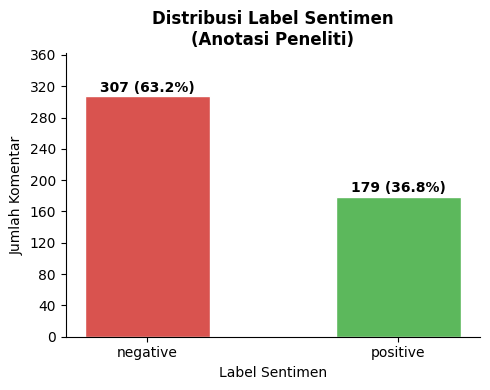

Total data  : 486
  Negatif   : 307 (63.2%)
  Positif   : 179 (36.8%)


/tmp/ipykernel_1666/15977606.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n = label_counts.get(lbl, 0) # Mengambil jumlah data untuk label terkait


In [2]:
# ============================================================
# DISTRIBUSI LABEL SENTIMEN (ANOTASI PENELITI)
# ============================================================
import matplotlib.pyplot as plt # Mengimpor pustaka matplotlib untuk membuat grafik/visualisasi data
import matplotlib.ticker as mticker # Mengimpor modul ticker untuk mengatur penanda (ticks) pada sumbu grafik

label_counts = my_df['label'].value_counts().sort_index() # Menghitung jumlah data per kelas label dan mengurutkannya berdasarkan indeks label (0, 1)
label_names  = {0: 'Negatif', 1: 'Positif'} # Membuat kamus (dictionary) untuk mengubah representasi angka menjadi teks label
labels_disp  = [label_names.get(l, str(l)) for l in label_counts.index] # Mengonversi indeks angka menjadi list teks ('Negatif', 'Positif') untuk tampilan sumbu X
colors       = ['#d9534f', '#5cb85c'] # Menentukan warna grafik batang (merah untuk Negatif, hijau untuk Positif)

fig, ax = plt.subplots(figsize=(5, 4)) # Membuat objek gambar (figure) dan area plot (axes) dengan ukuran 5x4 inci
bars = ax.bar(labels_disp, label_counts.values, color=colors,
              width=0.5, edgecolor='white') # Menggambar grafik batang berdasarkan data label dan jumlahnya dengan lebar batang 0.5

for bar, count in zip(bars, label_counts.values): # Melakukan perulangan untuk setiap batang guna memberikan teks label di atasnya
    pct = count / label_counts.sum() * 100 # Menghitung persentase kontribusi masing-masing kelas terhadap total data
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f'{count} ({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold') # Menampilkan teks jumlah data dan persentase tepat di atas tengah setiap batang

ax.set_title('Distribusi Label Sentimen\n(Anotasi Peneliti)',
             fontsize=12, fontweight='bold') # Mengatur judul grafik agar tebal dan berukuran 12
ax.set_xlabel('Label Sentimen', fontsize=10) # Memberikan label keterangan pada sumbu X
ax.set_ylabel('Jumlah Komentar', fontsize=10) # Memberikan label keterangan pada sumbu Y
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Memastikan skala angka pada sumbu Y selalu berupa bilangan bulat (tidak desimal)
ax.set_ylim(0, label_counts.max() * 1.18) # Memberikan ruang kosong (space) sebesar 18% di atas batang tertinggi agar teks angka tidak terpotong
ax.spines[['top', 'right']].set_visible(False) # Menyembunyikan garis tepi kotak bagian atas dan kanan agar grafik terlihat bersih dan modern
plt.tight_layout() # Mengatur tata letak elemen grafik secara otomatis agar tidak ada teks yang saling bertumpukan
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight') # Menyimpan grafik yang telah dibuat menjadi file gambar PNG berkualitas tinggi
plt.show() # Menampilkan grafik secara visual di layar program

print(f"Total data  : {label_counts.sum()}") # Mencetak total jumlah seluruh data komentar teks
for lbl, name in label_names.items(): # Melakukan perulangan untuk mencetak ringkasan teks di bawah grafik
    n = label_counts.get(lbl, 0) # Mengambil jumlah data untuk label terkait
    print(f"  {name:10s}: {n} ({n/label_counts.sum()*100:.1f}%)") # Mencetak jumlah dan persentase masing-masing kelas sentimen dalam bentuk teks ringkas

1.1. Handling Missing Value - Ignore Tuple

In [3]:
# Cek null
print("Jumlah null per kolom:") # Mencetak teks judul keterangan untuk hasil pengecekan data kosong
print(my_df.isnull().sum()) # Memeriksa setiap sel apakah bernilai null, lalu menjumlahkan total data null untuk masing-masing kolom

# Hapus baris yang labelnya kosong
my_df.dropna(subset=['label'], inplace=True) # Menghapus seluruh baris data jika ditemukan nilai kosong (null) khusus pada kolom 'label' secara permanen di DataFrame yang sama
print(f"\nJumlah baris setelah dropna: {len(my_df)}") # Menghitung dan menampilkan kembali total baris data yang tersisa setelah baris kosong dibersihkan
my_df.head(10) # Menampilkan 10 baris pertama data setelah pembersihan untuk memastikan struktur data tetap aman

Jumlah null per kolom:
label      0
content    0
dtype: int64

Jumlah baris setelah dropna: 486


,label,content
0,negative,Rumit
1,positive,"klo menurut saya, daftarnya jadi lebih mudah t..."
2,positive,mudah dan tidak serumit yang dibayangkan
3,positive,Alhamdulillah berarti bikin lebih cepet ya ini...
4,positive,gampang banget ternyata kalo daftar antrean on...
5,positive,sangat mudah apalagi untuk antrean onlinenya
6,positive,bagus sekali aslinya fitur antrean online ini
7,positive,pakai antrean online ini jadi lebih efisien so...
8,positive,antrean online ini lebih memudahkan
9,positive,aslinya gampang kok


In [4]:
# Hapus duplikat:
# Duplikat membuat model menghafal data yang sama berulang
# kali sehingga menyebabkan overfitting.

# Simpan dulu baris duplikat agar bisa ditampilkan
duplikat_df = my_df[my_df.duplicated(subset=['content'], keep='first')]  # Menyaring dan menyimpan baris data komentar yang duplikat (kemunculan kedua dan seterusnya) ke dalam 'duplikat_df' untuk dokumentasi

sebelum = len(my_df)  # Menghitung dan menyimpan total baris data sebelum dilakukan penghapusan data duplikat
my_df.drop_duplicates(subset=['content'], inplace=True)  # Menghapus baris data komentar yang duplikat secara permanen berdasarkan kesamaan teks pada kolom 'content'
sesudah = len(my_df)  # Menghitung dan menyimpan kembali total baris data yang tersisa setelah data duplikat dibersihkan

print(f"Data sebelum          : {sebelum}")  # Menampilkan total jumlah seluruh baris data sebelum dibersihkan
print(f"Data sesudah          : {sesudah}")  # Menampilkan total jumlah baris data yang tersisa setelah dibersihkan
print(f"Data duplikat dihapus : {sebelum - sesudah}")  # Menampilkan selisih atau jumlah total baris data duplikat yang berhasil dibuang
print(f"\nDistribusi label sekarang:")  # Mencetak teks pemisah untuk informasi sebaran kelas terbaru
print(my_df['label'].value_counts())  # Menghitung dan menampilkan kembali jumlah distribusi kelas (positif/negatif) pasca-pembersihan duplikat

print(f"\n=== DATA DUPLIKAT YANG DIHAPUS ({len(duplikat_df)} baris) ===")  # Mencetak teks judul pembuka untuk daftar sampel data yang dibuang beserta jumlah barisnya
print(duplikat_df[['content', 'label']].to_string())  # Mengonversi dan mencetak seluruh daftar teks komentar duplikat beserta labelnya ke dalam bentuk string utuh agar tidak terpotong saat ditampilkan

my_df.to_csv("mobilejknpreprocessing.csv", index=False)  # Menyimpan hasil DataFrame yang telah bersih dari null dan duplikat ke dalam file CSV baru tanpa menyertakan indeks kolom bawaan

Data sebelum          : 486
Data sesudah          : 477
Data duplikat dihapus : 9

Distribusi label sekarang:
label
negative    304
positive    173
Name: count, dtype: int64

=== DATA DUPLIKAT YANG DIHAPUS (9 baris) ===
                                                                                                                                                                                                                                             content     label
421                                                                                                                                                                                                   ternyata langkahnya simpel jadi mudah dipahami  positive
422                                                                                                                                                                                                                           simpel banget pakenyaa  positive
423            

1.2. Cleaning Komentar

Tahap ini membersihkan **seluruh** karakter yang tidak relevan dari teks komentar. Semua operasi penghapusan karakter dilakukan di sini agar tahap-tahap selanjutnya hanya bertanggung jawab atas satu fungsi masing-masing.

Yang ditangani pada tahap ini:
- **Unicode styled font** (`𝙂𝙖𝙠`, `𝐛𝐢𝐬𝐚`, dll.) — dikonversi ke ASCII padanannya terlebih dahulu sebelum cleaning (menggunakan `unicodedata.normalize('NFKD', ...)`)
- **Mention** (`@username`) — tidak membawa makna linguistik
- **URL** (`http://...`, `www....`) — tidak relevan untuk analisis sentimen
- **Tag HTML** (`<br>`, `<p>`, dll.) — artefak scraping
- **Entitas HTML** (`&amp;`, `&#39;`, dll.) — artefak encoding
- **Emoji, simbol, dan tanda baca** — semua karakter non-alfanumerik
- **Angka** — tidak relevan untuk sentimen teks

Catatan: Tahap Case Folding setelah ini **hanya** mengubah huruf menjadi huruf kecil, tanpa membuang karakter apapun.

In [5]:
import re
import unicodedata

def clean_komentar(text):
    if not isinstance(text, str):
        return ''
    # 0. Normalisasi Unicode styled font (contoh: 𝙂𝙖𝙠 → Gak)
    #    Mengkonversi Mathematical Alphanumeric Symbols dan karakter
    #    Unicode dekoratif ke padanan ASCII-nya sebelum cleaning.
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')
    # 1. Hapus mention (@username)
    text = re.sub(r'@\w+', '', text)
    # 2. Hapus URL (http/https dan www)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 3. Hapus tag HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # 4. Hapus entitas HTML (contoh: &amp; &#39; dll.)
    text = re.sub(r'&#\w+;|&\w+;', ' ', text)
    # 5. Hapus semua karakter non-alfanumerik:
    #    emoji, simbol, tanda baca, karakter khusus, dll.
    text = re.sub(r'[^0-9A-Za-z \t]', '', text)
    # 6. Hapus angka
    text = re.sub(r'\d+', '', text)
    # 7. Rapikan spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Simpan konten asli sebelum cleaning
my_df['content_raw'] = my_df['content'].copy()
my_df['content'] = my_df['content'].apply(clean_komentar)

print('Contoh teks setelah cleaning (hapus mention, URL, HTML, emoji, simbol, angka):')
print(my_df[['content']].head(10).to_string())
print(f'\nTotal data: {len(my_df)}')


Contoh teks setelah cleaning (hapus mention, URL, HTML, emoji, simbol, angka):
                                                                                              content
0                                                                                               Rumit
1                                            klo menurut saya daftarnya jadi lebih mudah tinggal klik
2                                                            mudah dan tidak serumit yang dibayangkan
3                    Alhamdulillah berarti bikin lebih cepet ya ini utk cara daftarnya tyt jg gampang
4                                    gampang banget ternyata kalo daftar antrean online di mobile JKN
5                                                        sangat mudah apalagi untuk antrean onlinenya
6                                                       bagus sekali aslinya fitur antrean online ini
7  pakai antrean online ini jadi lebih efisien soalnya cukup memangkas waktu pelayanan di pendaftaran
8  

2. Case Folding

Proses case folding mengubah seluruh huruf menjadi huruf kecil (lowercase). Pada tahap ini karakter 'A'–'Z' diubah menjadi 'a'–'z'. **Tidak ada penghapusan karakter apapun** di sini — semua simbol, emoji, dan karakter non-alfanumerik sudah dihapus sepenuhnya pada tahap Cleaning sebelumnya.

In [6]:
def case_folding(text):
    if not isinstance(text, str):
        return ''
    # Hanya konversi ke huruf kecil — tidak membuang karakter apapun
    return text.lower()

data_clean = my_df.copy()
data_clean['text_cf'] = data_clean['content'].apply(case_folding)

print('=== HASIL CASE FOLDING (10 baris pertama) ===')
print(data_clean[['content', 'text_cf']].head(10).to_string())
print(f'\nTotal data: {len(data_clean)}')


=== HASIL CASE FOLDING (10 baris pertama) ===
                                                                                              content                                                                                             text_cf
0                                                                                               Rumit                                                                                               rumit
1                                            klo menurut saya daftarnya jadi lebih mudah tinggal klik                                            klo menurut saya daftarnya jadi lebih mudah tinggal klik
2                                                            mudah dan tidak serumit yang dibayangkan                                                            mudah dan tidak serumit yang dibayangkan
3                    Alhamdulillah berarti bikin lebih cepet ya ini utk cara daftarnya tyt jg gampang                    alhamdulillah berarti bik

3. Normalisasi Teks

Setelah case folding, teks komentar dinormalisasi menggunakan kamus normalisasi. Kamus ini memetakan kata tidak baku, singkatan, dan variasi penulisan slang ke bentuk baku.

Kamus normalisasi bersifat **rule-based statis** — dimuat langsung dari `kamus_normalisasi.csv` (2.483 entri unik, satu pemetaan per kata slang — seluruh konflik pemetaan ganda sudah diresolusi manual, lihat catatan di kode). Karena kamus tidak dipelajari dari data (hanya aturan linguistik statis), tidak ada informasi yang bocor antara training dan test. Normalisasi diterapkan ke seluruh data sebelum split.

Catatan: Tahap ini **tidak** melakukan lowercase (sudah dilakukan di Case Folding) dan **tidak** menghapus simbol/HTML (sudah dilakukan di Cleaning).


In [7]:
import pandas as pd

# ============================================================
# KAMUS NORMALISASI — kamus_normalisasi.csv (SUDAH BERSIH)
# ============================================================
#
# File ini sudah final: 2.483 entri, SATU pemetaan per kata slang.
# Seluruh 16 slang yang sebelumnya punya >1 pemetaan berbeda
# (mis. 'gmn' -> 'bagaimana' vs 'gimana') sudah diresolusi manual
# menjadi satu nilai final. Ringkasan keputusan:
#
#   brjam->berjam, gacor->bagus, gercep->'gerak cepat',
#   gmn->bagaimana, gmna->bagaimana, kga->tidak, kyak->seperti,
#   ngisi->mengisi, sekip->lewat, sll->selalu, smpe->sampai,
#   tu->itu, y->ya, yaa->ya
#
#   DUA entri di antaranya bersifat AMBIGU secara makna dan dipilih
#   berdasarkan perkiraan penggunaan paling umum (bukan kepastian
#   linguistik) — cantumkan di bagian Keterbatasan jika ditanya:
#     - 'nj'  -> 'anjing' (bisa juga bermakna 'ini' tergantung konteks)
#     - 'x'   -> 'nya'    (bisa juga bermakna 'kali', mis. dalam angka)
#
# Kamus bersifat rule-based statis (tidak dipelajari dari data),
# aman diterapkan sebelum split — tidak ada informasi bocor.
# ============================================================

try:
    _df_kamus = pd.read_csv('/content/kamus_normalisasi.csv',
                            header=None,
                            names=['slang', 'baku'],
                            on_bad_lines='skip')
    _df_kamus = _df_kamus.dropna(subset=['slang', 'baku'])
    _df_kamus['slang'] = _df_kamus['slang'].str.strip()
    _df_kamus['baku'] = _df_kamus['baku'].str.strip()

    # Jaring pengaman: seharusnya sudah tidak ada slang dengan >1 pemetaan,
    # tapi tetap dicek agar error langsung kelihatan jika file berubah lagi.
    _sisa_konflik = _df_kamus[_df_kamus.duplicated('slang', keep=False)]['slang'].nunique()
    if _sisa_konflik > 0:
        print(f'PERINGATAN: masih ada {_sisa_konflik} slang dengan >1 pemetaan berbeda di kamus_normalisasi.csv!')
        _df_kamus = _df_kamus.drop_duplicates(subset='slang', keep='last')
    else:
        _df_kamus = _df_kamus.drop_duplicates(subset='slang', keep='first')

    kamus_normalisasi = dict(zip(_df_kamus['slang'], _df_kamus['baku']))

    print(f'kamus_normalisasi.csv berhasil dimuat: {len(kamus_normalisasi)} entri unik')
except FileNotFoundError:
    print('kamus_normalisasi.csv tidak ditemukan di /content/. Unggah file tersebut terlebih dahulu.')
    kamus_normalisasi = {}


kamus_normalisasi.csv berhasil dimuat: 2575 entri unik


In [8]:
def normalisasi_teks(text):
    if not isinstance(text, str):
        return ''
    # Tidak perlu lowercase (sudah dilakukan pada tahap Case Folding)
    # Tidak perlu hapus HTML/simbol (sudah dilakukan pada tahap Cleaning)
    kata_kata = text.split()
    kata_hasil = []
    for kata in kata_kata:
        if kata in kamus_normalisasi:
            kata_hasil.append(kamus_normalisasi[kata])
        else:
            kata_hasil.append(kata)
    return ' '.join(kata_hasil)

data_clean['content_norm'] = data_clean['text_cf'].apply(normalisasi_teks)

total_berubah = (data_clean['text_cf'] != data_clean['content_norm']).sum()
print(f'Total komentar        : {len(data_clean)}')
print(f'Komentar yang berubah : {total_berubah} ({total_berubah/len(data_clean)*100:.1f}%)')
print()
print('=== CONTOH PERBANDINGAN SEBELUM vs SESUDAH NORMALISASI ===')
for _, row in data_clean[data_clean['text_cf'] != data_clean['content_norm']].head(8).iterrows():
    print(f"ASLI  : {str(row['text_cf'])[:90]}")
    print(f"HASIL : {str(row['content_norm'])[:90]}")
    print()


Total komentar        : 477
Komentar yang berubah : 360 (75.5%)

=== CONTOH PERBANDINGAN SEBELUM vs SESUDAH NORMALISASI ===
ASLI  : klo menurut saya daftarnya jadi lebih mudah tinggal klik
HASIL : kalau menurut saya daftarnya jadi lebih mudah tinggal klik

ASLI  : alhamdulillah berarti bikin lebih cepet ya ini utk cara daftarnya tyt jg gampang
HASIL : alhamdulillah berarti membuat lebih cepat ya ini untuk cara daftarnya ternyata juga gampan

ASLI  : gampang banget ternyata kalo daftar antrean online di mobile jkn
HASIL : gampang banget ternyata kalau daftar antrean daring di mobile jkn

ASLI  : bagus sekali aslinya fitur antrean online ini
HASIL : bagus sekali aslinya fitur antrean daring ini

ASLI  : pakai antrean online ini jadi lebih efisien soalnya cukup memangkas waktu pelayanan di pen
HASIL : pakai antrean daring ini jadi lebih efisien soalnya cukup memangkas waktu pelayanan di pen

ASLI  : antrean online ini lebih memudahkan
HASIL : antrean daring ini lebih memudahkan

ASLI  : u

4. Tokenisasi

Proses tokenisasi memecah teks menjadi satuan kata (token) individual. Input adalah teks yang sudah di-case-fold dan dinormalisasi (`content_norm`).

In [9]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

data_clean['text_tokens'] = data_clean['content_norm'].apply(lambda x: word_tokenize(x))

print('=== HASIL TOKENISASI (10 baris pertama) ===')
data_clean[['content_norm', 'text_tokens']].head(10)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


=== HASIL TOKENISASI (10 baris pertama) ===


,content_norm,text_tokens
0,rumit,[rumit]
1,kalau menurut saya daftarnya jadi lebih mudah ...,"[kalau, menurut, saya, daftarnya, jadi, lebih,..."
2,mudah dan tidak serumit yang dibayangkan,"[mudah, dan, tidak, serumit, yang, dibayangkan]"
3,alhamdulillah berarti membuat lebih cepat ya i...,"[alhamdulillah, berarti, membuat, lebih, cepat..."
4,gampang banget ternyata kalau daftar antrean d...,"[gampang, banget, ternyata, kalau, daftar, ant..."
5,sangat mudah apalagi untuk antrean onlinenya,"[sangat, mudah, apalagi, untuk, antrean, onlin..."
6,bagus sekali aslinya fitur antrean daring ini,"[bagus, sekali, aslinya, fitur, antrean, darin..."
7,pakai antrean daring ini jadi lebih efisien so...,"[pakai, antrean, daring, ini, jadi, lebih, efi..."
8,antrean daring ini lebih memudahkan,"[antrean, daring, ini, lebih, memudahkan]"
9,aslinya gampang kok,"[aslinya, gampang, kok]"


5. Stopword Removal

Stopword removal menghapus kata-kata umum yang tidak membawa makna sentimen (misalnya: 'dan', 'yang', 'di', 'ke'). Input adalah hasil tokenisasi (`text_tokens`) berupa list token, sehingga penghapusan dilakukan langsung pada list.

**Catatan desain:** Word cloud pada versi awal masih memuat kata hubung, kata percakapan, dan kata yang hanya menunjukkan objek penelitian (mis. "aplikasi", "mobile", "jkn"). Untuk mengatasi hal ini, daftar stopword nltk bawaan diganti dengan **daftar stopword kustom** (`stopwords-id.txt`) yang sudah ditambahkan **domain-specific filtering** (kata objek penelitian seperti `aplikasi`, `mobile`, `jkn`, `bpjs`, `fitur`, `pendaftaran`, `pelayanan`, `antrean`, `online`).

`stopwords-id.txt` sudah dibersihkan secara langsung dari 12 kata bermuatan sentimen (`tidak`, `belum`, `tetapi`, `tapi`, `tanpa`, `bukan`, `jangan`, `kurang`, `baik`, `digunakan`, `sangat`, `sekali`) yang sebelumnya berisiko ikut terhapus dan membalik makna kalimat (mis. "tidak bagus" kehilangan negasinya jadi "bagus" saja). Daftar `keep_words` di kode tetap dipertahankan sebagai jaring pengaman kedua untuk kata-kata sentimen lain yang mungkin belum teridentifikasi.


In [10]:
# ============================================================
# STOPWORD REMOVAL -- stopwords-id.txt + kamus tambahan
# domain_object_words & netral_konektor_words tetap ada di text_steamindo
# (dipakai SVM), baru dibuang khusus di text_wc (WordCloud) di sel setelah Stemming.
# ============================================================

with open('/content/stopwords-id.txt', encoding='utf-8') as f:
    stop = [line.strip().lower() for line in f if line.strip()]

# Kata sentimen yang WAJIB dipertahankan (jangan ikut terbuang)
keep_words = ['tidak', 'belum', 'tetapi', 'kecuali', 'tapi', 'tanpa', 'nggak',
              'bukan', 'jangan', 'kurang', 'susah', 'sulit', 'bagus', 'baik',
              'mudah', 'cepat', 'lambat', 'buruk', 'digunakan', 'sangat', 'sekali',
              'gampang', 'sederhana', 'simpel', 'berhasil', 'suka', 'bermanfaat',
              'kecewa', 'error', 'gagal', 'lama', 'masih', 'banyak', 'orang',
              'awam', 'harus', 'makin']

# Kata objek/domain -- tetap ada di SVM, dibuang khusus di WordCloud
domain_object_words = ['aplikasi', 'mobile', 'jkn', 'bpjs', 'fitur', 'telepon', 'obat', 'pasien', 'sungguh', 'mati',
                        'pendaftaran', 'pelayanan', 'antrean', 'online', 'daring', 'rumah', 'iya', 'pas',
                        'sakit', 'pakai', 'indonesia', 'tua', 'terima', 'kasih', 'sehat', 'orang',
                        'masyarakat', 'rakyat', 'kontrol', 'ambil', 'tinggal', 'nomor', 'negara', 'coba', 'tulis', 'tidak', 'sangat', 'sekali']

# Konektor/intensifier netral -- tetap ada di SVM, dibuang khusus di WordCloud
netral_konektor_words = ['tapi', 'banget']

# Filler percakapan YouTube -- dibuang dari SVM & WordCloud (termasuk 'ya'/'nya')
filler_stopwords = ['ya', 'nya', 'sih', 'dong', 'deh', 'nih', 'kok', 'woy', 'gan',
                     'min', 'kak', 'bang', 'bro', 'sis', 'dl', 'dulu', 'nder',
                     'wkwk', 'wkwkwk', 'haha', 'hehe']

# Stopword final untuk MODEL (kata objek & konektor netral tetap ikut)
fix_stopwords = [w for w in set(stop) | set(filler_stopwords)
                 if w not in keep_words and w not in domain_object_words]

data_clean['text_StopWord'] = data_clean['text_tokens'].apply(
    lambda tokens: [w for w in tokens if w not in fix_stopwords]
)

print('=== HASIL STOPWORD REMOVAL (10 baris pertama) ===')
data_clean[['text_tokens', 'text_StopWord']].head(10)


=== HASIL STOPWORD REMOVAL (10 baris pertama) ===


,text_tokens,text_StopWord
0,[rumit],[rumit]
1,"[kalau, menurut, saya, daftarnya, jadi, lebih,...","[daftarnya, mudah, tinggal, klik]"
2,"[mudah, dan, tidak, serumit, yang, dibayangkan]","[mudah, tidak, serumit, dibayangkan]"
3,"[alhamdulillah, berarti, membuat, lebih, cepat...","[alhamdulillah, cepat, daftarnya, gampang]"
4,"[gampang, banget, ternyata, kalau, daftar, ant...","[gampang, banget, daftar, antrean, daring, mob..."
5,"[sangat, mudah, apalagi, untuk, antrean, onlin...","[sangat, mudah, antrean, onlinenya]"
6,"[bagus, sekali, aslinya, fitur, antrean, darin...","[bagus, sekali, aslinya, fitur, antrean, daring]"
7,"[pakai, antrean, daring, ini, jadi, lebih, efi...","[pakai, antrean, daring, efisien, memangkas, p..."
8,"[antrean, daring, ini, lebih, memudahkan]","[antrean, daring, memudahkan]"
9,"[aslinya, gampang, kok]","[aslinya, gampang]"


6. Stemming

In [11]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


In [12]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 1. Inisialisasi Stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemmed_wrapper(term):
    return stemmer.stem(term)

# 2. Bangun kamus stemming (term_dict) untuk menghemat waktu komputasi
term_dict = {}
for document in data_clean['text_StopWord']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '

print(f'Total kata unik yang akan di-stem: {len(term_dict)}')
print('------------------------')

# 3. Proses Stemming kata-kata unik
hitung = 0
for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)
    hitung += 1
    if hitung % 100 == 0 or hitung == len(term_dict):
        print(f'{hitung} : {term} : {term_dict[term]}')

print('------------------------')

def get_stemmed_term(document):
    return [term_dict[term] for term in document]

# 4. Terapkan hasil stemming ke dataset (Hasil Masih Mentah)
data_clean['text_steamindo_raw'] = data_clean['text_StopWord'].apply(
    lambda x: ' '.join(get_stemmed_term(x))
)

# ==============================================================================
# PASS KE-2 (POST-STEMMING) — Memisahkan Alur untuk MODEL SVM dan WORD CLOUD
# ==============================================================================
# Antisipasi jika ada stopword umum atau kata objek yang berubah bentuk setelah di-stem
# (misal: "mendaftar" menjadi "daftar", "pelayanannya" menjadi "layan").
# ==============================================================================

# A. Stemming kamus stopword dan daftar kata objek agar bentuk akarnya cocok
stop_stemmed = set(stemmed_wrapper(w) for w in fix_stopwords)
domain_stemmed = set(stemmed_wrapper(w) for w in domain_object_words)

# FIX (kolisi stemming): kata stopword lain yang stem-nya kebetulan SAMA
# dengan salah satu keep_words bisa ikut menghapus keep_words tsb secara
# tidak sengaja. Contoh nyata yang ditemukan: 'bukannya' -> stem -> 'bukan',
# 'seorang' -> stem -> 'orang'. Karena 'bukan' & 'orang' ada di keep_words,
# bentuk stem itu WAJIB dikeluarkan lagi dari stop_stemmed di sini, supaya
# proteksi keep_words benar-benar berlaku sampai ke tahap pasca-stemming ini.
keep_words_stemmed = set(stemmed_wrapper(w) for w in keep_words)
stop_stemmed = stop_stemmed - keep_words_stemmed

# B. Kolom 1: text_steamindo (UNTUK MODEL SVM)
# Stopword umum dibuang, tetapi kata objek (aplikasi, bpjs, jkn, dll) TETAP ADA
data_clean['text_steamindo'] = data_clean['text_steamindo_raw'].apply(
    lambda text: ' '.join(w for w in text.split() if w not in stop_stemmed)
)

# C. Kolom 2: text_wc (UNTUK VISUALISASI WORD CLOUD & TABEL FREKUENSI)
# Turunan langsung dari text_steamindo yang dibersihkan total dari kata objek penelitian
data_clean['text_wc'] = data_clean['text_steamindo'].apply(
    lambda text: ' '.join(w for w in text.split() if w not in domain_stemmed)
)

print('Stemming selesai!')
print("1. Kolom data_clean['text_steamindo'] (Ada kata objek) -> Siap digunakan untuk SVM.")
print("2. Kolom data_clean['text_wc'] (Bebas kata objek) -> Siap digunakan untuk Word Cloud & Tabel Frekuensi.")

Total kata unik yang akan di-stem: 789
------------------------
100 : muncul : muncul
200 : lansia : lansia
300 : yasemoga : yasemoga
400 : daftrnya : daftrnya
500 : mencoba : coba
600 : visi : visi
700 : verifikasi : verifikasi
789 : diabaikan : abai
------------------------
Stemming selesai!
1. Kolom data_clean['text_steamindo'] (Ada kata objek) -> Siap digunakan untuk SVM.
2. Kolom data_clean['text_wc'] (Bebas kata objek) -> Siap digunakan untuk Word Cloud & Tabel Frekuensi.


In [13]:
# Ambil kata objek + konektor/intensifier netral yang sudah disesuaikan
# dengan hasil stemming (FIX: sebelumnya netral_konektor_words -- 'tapi',
# 'banget' -- belum ikut dibuang dari text_wc, itu sebabnya keduanya masih
# nongol di top-10 word cloud Positif MAUPUN Negatif).
domain_stemmed = set(stemmed_wrapper(w) for w in domain_object_words)
konektor_stemmed = set(stemmed_wrapper(w) for w in netral_konektor_words)
kata_dibuang_dari_wc = domain_stemmed | konektor_stemmed

def strip_domain_words(text):
    return ' '.join(w for w in text.split() if w not in kata_dibuang_dari_wc)

# Kolom text_wc HANYA untuk Word Cloud & Bigram/Trigram
data_clean['text_wc'] = data_clean['text_steamindo'].apply(strip_domain_words)

In [14]:
# Cek komentar NEGATIF yang mengandung 'mudah' — apakah memang didahului negasi?
negasi = ['tidak', 'kurang', 'belum', 'nggak', 'gak', 'susah']

mask = (data_clean['label'] == 'negative') & (data_clean['text_steamindo'].str.contains(r'\bmudah\b', regex=True))
subset = data_clean.loc[mask, ['content_raw', 'text_steamindo']]

print(f"Total komentar negatif mengandung 'mudah': {len(subset)}")

def ada_negasi_dekat(text, kata='mudah', window=2):
    tokens = text.split()
    for i, t in enumerate(tokens):
        if t == kata:
            sekitar = tokens[max(0,i-window):i]
            if any(n in sekitar for n in negasi):
                return True
    return False

subset['didahului_negasi'] = subset['text_steamindo'].apply(ada_negasi_dekat)
print(subset['didahului_negasi'].value_counts())
print()
print(subset[['content_raw']].head(15).to_string())

Total komentar negatif mengandung 'mudah': 36
didahului_negasi
False    31
True      5
Name: count, dtype: int64

                                                                                                                                                                                                                                                                               content_raw
11                                                                                                                                                                                                                                           Bilangnya sangat mudah <br>Kenyataannya ribet
14                                                                                                                                                                                          Betul sekali, di indo ini aneh aplikasi diperbaharui bukannya tambah mudah malah tambah ribet.
55                                   

### Perbandingan Hasil Seluruh Tahap Preprocessing

Tabel berikut menampilkan seluruh data setelah melewati semua tahap preprocessing: Cleaning → Case Folding → Normalisasi → Tokenisasi → Stopword Removal → Stemming.

In [15]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 60)

# Kolom yang ditampilkan sesuai urutan tahap preprocessing
kolom_tampil = [
    'label',
    'content_raw',    # sebelum Cleaning (teks asli)
    'content',        # setelah Cleaning
    'text_cf',        # setelah Case Folding
    'content_norm',   # setelah Normalisasi
    'text_tokens',    # setelah Tokenisasi
    'text_StopWord',  # setelah Stopword Removal
    'text_steamindo'  # setelah Stemming (final)
]

df_tampil = data_clean[kolom_tampil].copy()

print(f'Total data: {len(df_tampil)} baris')
print(f'Kolom: {list(df_tampil.columns)}')
print()
display(df_tampil)


Total data: 477 baris
Kolom: ['label', 'content_raw', 'content', 'text_cf', 'content_norm', 'text_tokens', 'text_StopWord', 'text_steamindo']



,label,content_raw,content,text_cf,content_norm,text_tokens,text_StopWord,text_steamindo
0,negative,Rumit,Rumit,rumit,rumit,[rumit],[rumit],rumit
1,positive,"klo menurut saya, daftarnya jadi lebih mudah tinggal klik²",klo menurut saya daftarnya jadi lebih mudah tinggal klik,klo menurut saya daftarnya jadi lebih mudah tinggal klik,kalau menurut saya daftarnya jadi lebih mudah tinggal klik,"[kalau, menurut, saya, daftarnya, jadi, lebih, mudah, ti...","[daftarnya, mudah, tinggal, klik]",daftar mudah tinggal klik
2,positive,mudah dan tidak serumit yang dibayangkan,mudah dan tidak serumit yang dibayangkan,mudah dan tidak serumit yang dibayangkan,mudah dan tidak serumit yang dibayangkan,"[mudah, dan, tidak, serumit, yang, dibayangkan]","[mudah, tidak, serumit, dibayangkan]",mudah tidak rumit bayang
3,positive,Alhamdulillah berarti bikin lebih cepet ya ini utk cara ...,Alhamdulillah berarti bikin lebih cepet ya ini utk cara ...,alhamdulillah berarti bikin lebih cepet ya ini utk cara ...,alhamdulillah berarti membuat lebih cepat ya ini untuk c...,"[alhamdulillah, berarti, membuat, lebih, cepat, ya, ini,...","[alhamdulillah, cepat, daftarnya, gampang]",alhamdulillah cepat daftar gampang
4,positive,gampang banget ternyata kalo daftar antrean online di mo...,gampang banget ternyata kalo daftar antrean online di mo...,gampang banget ternyata kalo daftar antrean online di mo...,gampang banget ternyata kalau daftar antrean daring di m...,"[gampang, banget, ternyata, kalau, daftar, antrean, dari...","[gampang, banget, daftar, antrean, daring, mobile, jkn]",gampang banget daftar antre daring mobile jkn
5,positive,sangat mudah apalagi untuk antrean onlinenya,sangat mudah apalagi untuk antrean onlinenya,sangat mudah apalagi untuk antrean onlinenya,sangat mudah apalagi untuk antrean onlinenya,"[sangat, mudah, apalagi, untuk, antrean, onlinenya]","[sangat, mudah, antrean, onlinenya]",sangat mudah antre onlinenya
6,positive,bagus sekali aslinya fitur antrean online ini,bagus sekali aslinya fitur antrean online ini,bagus sekali aslinya fitur antrean online ini,bagus sekali aslinya fitur antrean daring ini,"[bagus, sekali, aslinya, fitur, antrean, daring, ini]","[bagus, sekali, aslinya, fitur, antrean, daring]",bagus sekali asli fitur antre daring
7,positive,pakai antrean online ini jadi lebih efisien soalnya cuku...,pakai antrean online ini jadi lebih efisien soalnya cuku...,pakai antrean online ini jadi lebih efisien soalnya cuku...,pakai antrean daring ini jadi lebih efisien soalnya cuku...,"[pakai, antrean, daring, ini, jadi, lebih, efisien, soal...","[pakai, antrean, daring, efisien, memangkas, pelayanan, ...",pakai antre daring efisien mangkas layan daftar
8,positive,antrean online ini lebih memudahkan,antrean online ini lebih memudahkan,antrean online ini lebih memudahkan,antrean daring ini lebih memudahkan,"[antrean, daring, ini, lebih, memudahkan]","[antrean, daring, memudahkan]",antre daring mudah
9,positive,aslinya gampang kok,aslinya gampang kok,aslinya gampang kok,aslinya gampang kok,"[aslinya, gampang, kok]","[aslinya, gampang]",asli gampang


In [16]:
data_clean.to_csv('hasil_TextPreProcessing_MOBILEJKN.csv', index=False)
print("File berhasil disimpan!")
print(f"Total data: {len(data_clean)}")
print(f"\nDistribusi label akhir:")
print(data_clean['label'].value_counts())

File berhasil disimpan!
Total data: 477

Distribusi label akhir:
label
negative    304
positive    173
Name: count, dtype: int64


7. WordCloud

**Catatan desain:** Word cloud versi awal masih menampilkan kata seperti "daftar", "antre", "aplikasi", "jkn" — kata objek penelitian / kata umum yang tidak membawa muatan sentimen.

**Arsitektur final (2 kolom, disengaja, bukan kesalahan):**
- `text_steamindo` — hasil akhir preprocessing (cleaning → case folding → normalisasi → tokenisasi → stopword removal → stemming). Kata objek domain (aplikasi, jkn, bpjs, dst.) **sengaja dipertahankan** di sini. Kolom ini **HANYA** dipakai untuk TF-IDF → SVM (tahap Splitting Data dst.).
- `text_wc` — dibuat dari `text_steamindo` + filter tambahan yang membuang kata objek domain (lihat sel setelah Stemming). Kolom ini **HANYA** dipakai untuk WordCloud, tabel kata teratas, dan bigram/trigram di bawah.

**Kenapa dipisah:** Perbaikan ini menyasar **kualitas visualisasi/interpretasi**, bukan performa model. Supaya perbaikan ini tidak berisiko mengubah hasil SVM yang sudah diperoleh, filter kata objek domain **hanya diterapkan pada jalur visualisasi**, tidak pada jalur pemodelan. Ini adalah bentuk *feature selection* yang diterapkan secara sengaja dan terbatas ruang lingkupnya (bukan diterapkan serampangan ke semua bagian).


In [17]:
# ==============================================================================
# KONFIRMASI: DUA KOLOM FINAL DENGAN TUJUAN BERBEDA
# ==============================================================================
# text_steamindo -> dipakai HANYA untuk Splitting Data -> TF-IDF -> SVM
# text_wc         -> dipakai HANYA untuk WordCloud, tabel kata, bigram/trigram
#                    (text_steamindo + filter kata objek domain, dibuat di
#                    sel setelah Stemming di atas)
# ==============================================================================

print('Kolom untuk SVM (TF-IDF)      : text_steamindo (kata objek domain tetap ada)')
print('Kolom untuk WordCloud/n-gram  : text_wc (kata objek domain sudah dibuang)')
print(f'Total data: {len(data_clean)}')
display(data_clean[['text_steamindo', 'text_wc']].head(10))


Kolom untuk SVM (TF-IDF)      : text_steamindo (kata objek domain tetap ada)
Kolom untuk WordCloud/n-gram  : text_wc (kata objek domain sudah dibuang)
Total data: 477


,text_steamindo,text_wc
0,rumit,rumit
1,daftar mudah tinggal klik,mudah klik
2,mudah tidak rumit bayang,mudah rumit bayang
3,alhamdulillah cepat daftar gampang,alhamdulillah cepat gampang
4,gampang banget daftar antre daring mobile jkn,gampang
5,sangat mudah antre onlinenya,mudah onlinenya
6,bagus sekali asli fitur antre daring,bagus asli
7,pakai antre daring efisien mangkas layan daftar,efisien mangkas
8,antre daring mudah,mudah
9,asli gampang,asli gampang


WordCloud dibuat dari 477 komentar (Sumber data: data_clean['text_wc'])
   Positif: 173 komentar
   Negatif: 304 komentar
   MAX_WORDS: 10


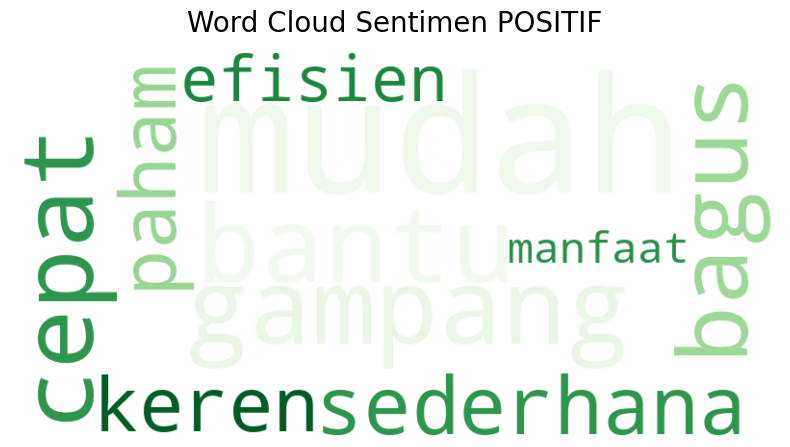

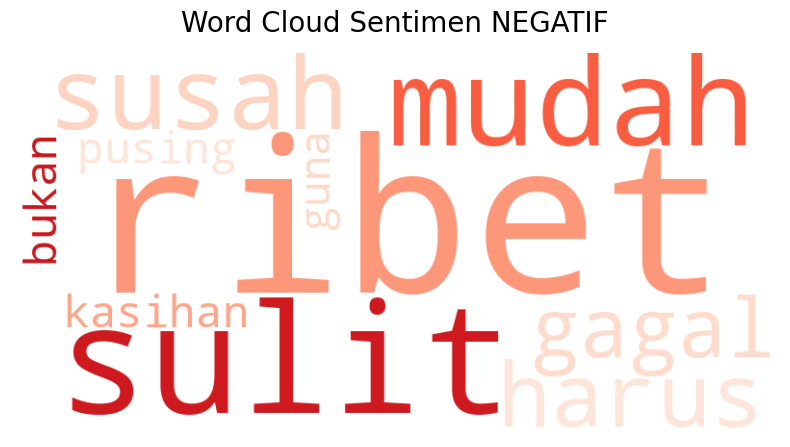

In [18]:
!pip install wordcloud

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# CATATAN: memakai data_clean['text_wc'] (bukan text_steamindo) agar kata
# objek domain (aplikasi, jkn, bpjs, dst.) tidak mendominasi visualisasi.
#
# MAX_WORDS: ini HANYA membatasi berapa banyak kata TERATAS yang ditampilkan,
# BUKAN mekanisme yang memastikan kata itu bermuatan sentimen. Kalau
# text_wc sudah difilter dengan benar (domain_object_words di sel Stopword
# Removal), maka kata-kata yang PALING SERING muncul di text_wc SEHARUSNYA
# sudah didominasi kata sentimen -- MAX_WORDS tinggal soal selera visual
# (mau padat/ramai atau ringkas/fokus), bukan soal benar/salah.
# Kalau MAX_WORDS diset kecil (mis. 15) TAPI filtering domain_object_words
# belum lengkap, kata objek yang lolos filter tetap bisa muncul di 15 besar
# itu -- jadi akar masalahnya tetap ada di daftar domain_object_words,
# bukan di angka MAX_WORDS ini.
MAX_WORDS = 10  # maksimal 10 kata teratas

# ============================================================
# KETERBATASAN PENTING (ditemukan dari word cloud aktual):
# Word cloud UNIGRAM ini TIDAK BISA menangkap negasi. Kata 'mudah'
# tetap bisa jadi top-word di kelas NEGATIF kalau konteks aslinya
# 'tidak mudah'/'kurang mudah' -- unigram memisah 'tidak' dan 'mudah'
# jadi dua kata terpisah, padahal maknanya justru berlawanan arah.
# Word cloud ini HANYA gambaran kasar kata yang sering muncul, BUKAN
# representasi akurat arah sentimen per kata. Untuk interpretasi
# sentimen yang lebih bermakna, gunakan
# Word Cloud & Tabel BIGRAM/TRIGRAM di bagian 7.1/7.2 di bawah sebagai
# rujukan UTAMA -- karena frasa 2-3 kata ('tidak mudah', 'susah
# digunakan') tetap menyatu dan tidak kehilangan konteks negasi.
# ============================================================

text_positif = " ".join(data_clean[data_clean['label'] == 'positive']['text_wc'].astype(str))
text_negatif = " ".join(data_clean[data_clean['label'] == 'negative']['text_wc'].astype(str))

def buat_wordcloud(text, title, color):
    if not text.strip():
        print(f"Tidak ada data untuk {title}")
        return

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=color,
        max_words=MAX_WORDS,
        min_font_size=10,
        collocations=False,  # False = WordCloud TIDAK otomatis menggabungkan kata jadi bigram sendiri
                              # (mencegah artefak aneh spt "tidak_bisa" nempel jadi 1 kata acak).
                              # Bigram/trigram yang sebenarnya sudah dianalisis TERPISAH di bagian 7.1/7.2.
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=20, pad=15)
    plt.show()

print(f"WordCloud dibuat dari {len(data_clean)} komentar (Sumber data: data_clean['text_wc'])")
print(f"   Positif: {(data_clean['label'] == 'positive').sum()} komentar")
print(f"   Negatif: {(data_clean['label'] == 'negative').sum()} komentar")
print(f"   MAX_WORDS: {MAX_WORDS}")

buat_wordcloud(text_positif, 'Word Cloud Sentimen POSITIF', 'Greens')
buat_wordcloud(text_negatif, 'Word Cloud Sentimen NEGATIF', 'Reds')


In [19]:
# ==============================================================================
# TABEL KATA TERATAS WORD CLOUD PER KELAS SENTIMEN
# ==============================================================================
# Memakai data_clean['text_wc'] (bukan text_steamindo) agar konsisten dengan
# WordCloud di atas -- kata objek domain sudah dibuang dari kolom ini.
# ==============================================================================

import pandas as pd
from collections import Counter

TOP_N = 10  # ganti angka ini sesuai kebutuhan

hasil_tabel = []
for label in ['positive', 'negative']:
    teks_gabung = " ".join(
        data_clean[data_clean['label'] == label]['text_wc'].astype(str)
    )
    kata_list = teks_gabung.split()
    counter = Counter(kata_list)
    top_kata = counter.most_common(TOP_N)

    for rank, (kata, frekuensi) in enumerate(top_kata, start=1):
        hasil_tabel.append({
            'Sentimen'  : label.capitalize(),
            'Peringkat' : rank,
            'Kata'      : kata,
            'Frekuensi' : frekuensi
        })

df_top_kata = pd.DataFrame(hasil_tabel)

print(f'TABEL {TOP_N} KATA TERATAS PER KELAS SENTIMEN')
print(f'Sumber: data_clean["text_wc"] ({len(data_clean)} komentar)')
print()

for label in ['Positive', 'Negative']:
    subset = df_top_kata[df_top_kata['Sentimen'] == label][['Peringkat', 'Kata', 'Frekuensi']]
    print(f'--- Sentimen {label} ---')
    print(subset.to_string(index=False))
    print()

print('CEK MANUAL: kalau masih ada kata objek/netral (bukan sentimen) di')
print('tabel di atas, tambahkan ke domain_object_words di sel setelah Stemming.')


TABEL 10 KATA TERATAS PER KELAS SENTIMEN
Sumber: data_clean["text_wc"] (477 komentar)

--- Sentimen Positive ---
 Peringkat      Kata  Frekuensi
         1     mudah         70
         2   gampang         22
         3     bantu         22
         4     cepat         20
         5     bagus         18
         6 sederhana         12
         7     paham         11
         8     keren         11
         9   efisien         10
        10   manfaat         10

--- Sentimen Negative ---
 Peringkat    Kata  Frekuensi
         1   ribet        129
         2   sulit         56
         3   mudah         36
         4   susah         31
         5   harus         24
         6   gagal         23
         7  pusing         11
         8 kasihan         11
         9   bukan         11
        10    guna         10

CEK MANUAL: kalau masih ada kata objek/netral (bukan sentimen) di
tabel di atas, tambahkan ke domain_object_words di sel setelah Stemming.


### 7.1 Analisis Bigram & Trigram

Visualisasi word cloud (unigram) masih dapat menampilkan kata yang ambigu tanpa konteks. Analisis bigram (2 kata berurutan) dan trigram (3 kata berurutan) ditambahkan agar pola sentimen lebih bermakna, misalnya frasa seperti "tidak bisa", "sangat membantu", atau "susah sekali" yang tidak tertangkap oleh analisis kata tunggal.

Sumber data: `data_clean['text_wc']` (sama dengan word cloud di atas — kata objek domain sudah dibuang), dipisah per kelas sentimen (`positive` / `negative`).


In [20]:
# ==============================================================================
# TABEL BIGRAM & TRIGRAM TERATAS PER KELAS SENTIMEN
# ==============================================================================
# CATATAN:
#   - KONSISTEN Memakai data_clean['text_wc'] (bebas kata objek/prosedural)
#     agar sinkron dengan Word Cloud utama.
#   - Frekuensi dihitung dari seluruh data (bukan hanya train/test),
#     konsisten dengan pendekatan visualisasi (bukan bagian evaluasi model).
#   - CountVectorizer di sini murni untuk penghitungan frekuensi n-gram,
#     BUKAN vektorisasi fitur untuk model SVM (yang tetap memakai TF-IDF
#     dari text_steamindo pada tahap Vektorisasi Data terpisah).
# ==============================================================================

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

TOP_N_NGRAM = 10

# Frasa yang dibuang manual dari analisis bigram/trigram (nama orang, artefak
# stemming/data kotor, atau frasa objek yang tidak bermuatan sentimen)
EXCLUDED_NGRAMS = {
    'griya luka', 'klik klik', 'tinggal klik', 'mesin anjung', 'hubung server', 'akibat pulang mending', 'alih pandawaribet amot', 'abang alhamdulillah rujuk', 'ampun bayar gratis', 'duduk manis', 'abang sangattt manfaat',
    'tinggal klik klik', 'ghufron mukti dirut', 'ali ghufron mukti', 'keren sukses ali', 'adu pandawa solusi', 'aduh puya gimana', 'aja pol tunggu', 'dirut promosi', 'sukses ali ghufron', 'akses masyarat awam',
    'adanama anakkudan nama', 'loket mesin anjung', 'bain tidur malam', 'admin tahap ngapain', 'mukti dirut promosi', 'mesin anjung tugas', 'ali ghufron', 'ngopi klik klik', 'tidur malam jam', 'anakkudan nama pusing', 'adaptasi cita emas',
    'aneh baharu mudah', 'ajar pelan gagap', 'mudah tidak', 'gampang tidak ngopi', 'jam orang manual', 'malam jam tidak', 'orang tidak erti',
    'tidak kuota tidak', 'adu pandawa tidak', 'orang tidak'
}

def top_ngrams(corpus, ngram_range, top_n=10, exclude=EXCLUDED_NGRAMS):
    """Mengembalikan daftar (n-gram, frekuensi) teratas dari sebuah korpus teks."""
    corpus = [t for t in corpus if isinstance(t, str) and t.strip()]
    if not corpus:
        return []
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    matrix = vectorizer.fit_transform(corpus)
    freqs = matrix.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    pairs = [(kata, freq) for kata, freq in zip(vocab, freqs) if kata not in exclude]
    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
    return pairs[:top_n]

hasil_ngram = []

for label in ['positive', 'negative']:
    # PERBAIKAN: Menggunakan text_wc agar kata objek tidak masuk ke analisis tabel
    corpus_label = data_clean[data_clean['label'] == label]['text_wc'].astype(str).tolist()

    for ngram_name, ngram_range in [('Bigram', (2, 2)), ('Trigram', (3, 3))]:
        top_pairs = top_ngrams(corpus_label, ngram_range, TOP_N_NGRAM)
        for rank, (frasa, frekuensi) in enumerate(top_pairs, start=1):
            hasil_ngram.append({
                'Sentimen'  : label.capitalize(),
                'Jenis'     : ngram_name,
                'Peringkat' : rank,
                'Frasa'     : frasa,
                'Frekuensi' : frekuensi
            })

df_ngram = pd.DataFrame(hasil_ngram)

print(f'TABEL {TOP_N_NGRAM} BIGRAM & TRIGRAM TERATAS PER KELAS SENTIMEN')
print(f'Sumber: data_clean["text_wc"] ({len(data_clean)} komentar)')
print()

for label in ['Positive', 'Negative']:
    for ngram_name in ['Bigram', 'Trigram']:
        subset = df_ngram[(df_ngram['Sentimen'] == label) & (df_ngram['Jenis'] == ngram_name)][['Peringkat', 'Frasa', 'Frekuensi']]
        print(f'--- {ngram_name} - Sentimen {label} ---')
        print(subset.to_string(index=False))
        print()

TABEL 10 BIGRAM & TRIGRAM TERATAS PER KELAS SENTIMEN
Sumber: data_clean["text_wc"] (477 komentar)

--- Bigram - Sentimen Positive ---
 Peringkat           Frasa  Frekuensi
         1     mudah paham         10
         2 sederhana mudah          6
         3     bantu mudah          4
         4     tanpa harus          4
         5 teknologi bagus          4
         6     bagus cepat          3
         7   mudah periksa          3
         8    asli gampang          2
         9   cepat panggil          2
        10    cepat proses          2

--- Trigram - Sentimen Positive ---
 Peringkat                   Frasa  Frekuensi
         1   sederhana mudah paham          5
         2      bagus cepat proses          2
         3      gampang ngopi klik          2
         4       klik keren sukses          2
         5         klik klik keren          2
         6    maju teknologi bagus          2
         7     mudah paham langkah          2
         8   paham langkah langkah         

### 7.2 Word Cloud Bigram & Trigram (Visualisasi Tambahan)

Word cloud berikut memvisualisasikan bigram (frasa 2 kata) dan trigram (frasa 3 kata) teratas per kelas sentimen, sebagai pelengkap tabel di atas. Frasa ditampilkan dengan tanda hubung (`_`) antar kata karena `WordCloud` memperlakukan setiap entri sebagai satu token. Maksimal 10 frasa teratas ditampilkan per Word Cloud.

Catatan: exclude kata dilakukan manual (menambah ke `domain_object_words` / `netral_konektor_words` di sel Stopword Removal), bukan lewat parameter di sel ini.

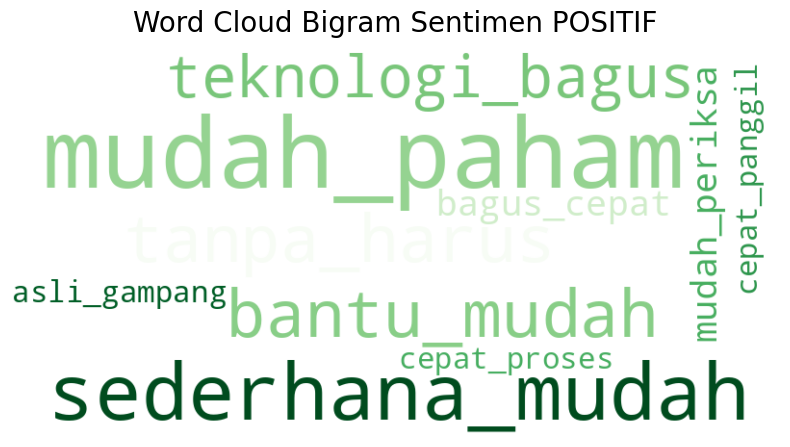

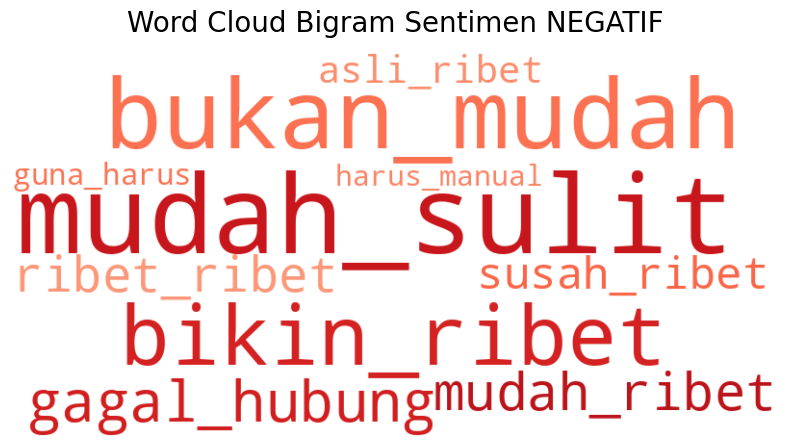

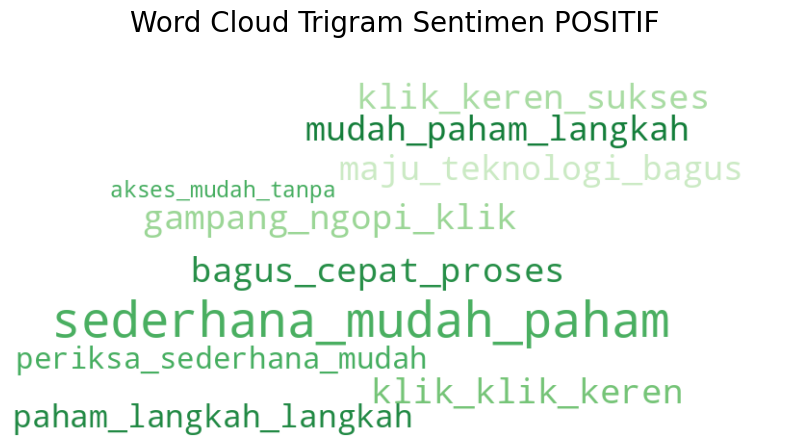

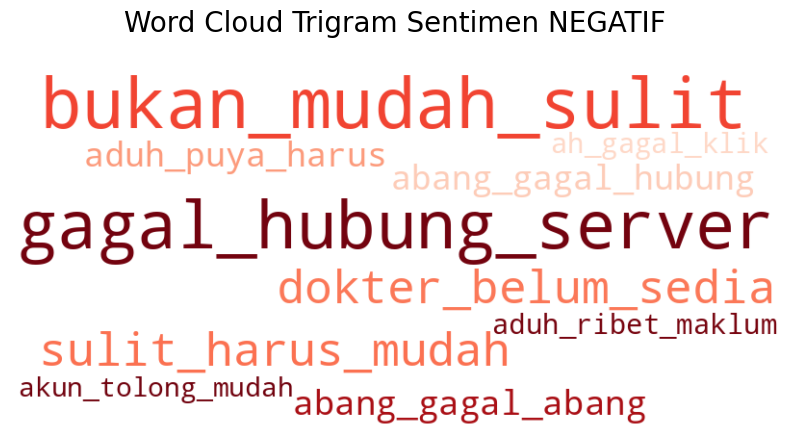

In [21]:
# ==============================================================================
# WORD CLOUD UNIGRAM SUDAH DI ATAS. DI SINI: BIGRAM & TRIGRAM PER KELAS SENTIMEN
# ------------------------------------------------------------
# Ini bukan visualisasi tambahan/opsional -- ini rujukan UTAMA untuk
# interpretasi arah sentimen. Word cloud unigram di atas terbukti bisa
# menyesatkan (mis. 'mudah' nongol di kelas Negatif akibat negasi
# 'tidak mudah' yang kepisah jadi kata tunggal). Bigram/trigram menjaga
# frasa tetap utuh sehingga makna sentimennya lebih valid dibaca.
# ==============================================================================
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

def buat_wordcloud_ngram(corpus, ngram_range, title, color, max_words=50, exclude=EXCLUDED_NGRAMS):
    corpus = [t for t in corpus if isinstance(t, str) and t.strip()]
    if not corpus:
        print(f"Tidak ada data untuk {title}")
        return
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    matrix = vectorizer.fit_transform(corpus)
    freqs = matrix.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()

    # Supaya terlihat rapi di Word Cloud, spasi diganti dengan underscore '_'
    # Frasa yang ada di EXCLUDED_NGRAMS (dari sel TABEL BIGRAM & TRIGRAM di atas) dibuang
    freq_dict = {kata.replace(' ', '_'): int(freq) for kata, freq in zip(vocab, freqs)
                 if kata not in exclude}
    if not freq_dict:
        print(f"Tidak ada data untuk {title}")
        return
    wordcloud = WordCloud(
        width=800, height=400, background_color='white',
        colormap=color, max_words=max_words
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=20, pad=15)
    plt.show()

# PERBAIKAN: Menggunakan text_wc agar visualisasi bigram bersih dari kata objek
corpus_positif = data_clean[data_clean['label'] == 'positive']['text_wc'].astype(str).tolist()
corpus_negatif = data_clean[data_clean['label'] == 'negative']['text_wc'].astype(str).tolist()

# Jalankan fungsi visualisasi
buat_wordcloud_ngram(corpus_positif, (2, 2), 'Word Cloud Bigram Sentimen POSITIF', 'Greens', max_words=10)
buat_wordcloud_ngram(corpus_negatif, (2, 2), 'Word Cloud Bigram Sentimen NEGATIF', 'Reds', max_words=10)

# Word Cloud Trigram (ditambahkan sesuai permintaan -- exclude kata dilakukan manual
# lewat domain_object_words/netral_konektor_words di sel Stopword Removal, bukan lewat kode ini)
buat_wordcloud_ngram(corpus_positif, (3, 3), 'Word Cloud Trigram Sentimen POSITIF', 'Greens', max_words=10)
buat_wordcloud_ngram(corpus_negatif, (3, 3), 'Word Cloud Trigram Sentimen NEGATIF', 'Reds', max_words=10)

8. Splitting Data

Data training bertujuan untuk mengembangkan model
Data Testing bertujuan untuk mengukur performansi model
memecah data test 20% dari keseluruhan data

### Verifikasi Deduplikasi Pasca-Stemming: Konsistensi Label

**Tujuan:** memastikan bahwa deduplikasi `text_steamindo` (di sel Splitting Data berikutnya) tidak membuang informasi label yang berbeda secara diam-diam. Deduplikasi ini hanya sah untuk analisis sentimen jika **setiap kelompok komentar yang menjadi identik setelah stemming memiliki label yang sama** -- kalau ada kelompok dengan label berbeda, artinya stemming menghilangkan informasi yang justru penting untuk membedakan sentimen, dan itu perlu didokumentasikan sebagai keterbatasan, bukan dihapus diam-diam.

Sel ini dijalankan **SEBELUM** `drop_duplicates` di sel Splitting Data (pada `data_clean` yang masih utuh), sehingga menampilkan seluruh 38 komentar yang akan terpengaruh beserta label aslinya.


In [22]:
import pandas as pd

# ============================================================
# VERIFIKASI: apakah deduplikasi text_steamindo aman untuk sentimen?
# ============================================================

# Tandai seluruh baris yang termasuk dalam kelompok duplikat (bukan cuma yang akan dibuang)
mask_duplikat = data_clean.duplicated(subset=['text_steamindo'], keep=False)
grup_duplikat = data_clean[mask_duplikat].sort_values('text_steamindo')

n_baris_terlibat = len(grup_duplikat)
n_kelompok = grup_duplikat['text_steamindo'].nunique()
n_akan_dibuang = n_baris_terlibat - n_kelompok  # setiap kelompok menyisakan 1, sisanya dibuang

print('=' * 90)
print('VERIFIKASI DEDUPLIKASI PASCA-STEMMING')
print('=' * 90)
print(f'Jumlah kelompok text_steamindo yang terduplikasi : {n_kelompok}')
print(f'Total baris yang terlibat dalam kelompok ini      : {n_baris_terlibat}')
print(f'Baris yang akan DIBUANG oleh drop_duplicates      : {n_akan_dibuang}')
print()

# Cek konsistensi label per kelompok
cek_label = grup_duplikat.groupby('text_steamindo')['label'].nunique()
kelompok_bermasalah = cek_label[cek_label > 1]

if len(kelompok_bermasalah) == 0:
    print('✅ AMAN: Seluruh kelompok duplikat memiliki label SENTIMEN YANG SAMA.')
    print('   Tidak ada informasi label yang hilang akibat deduplikasi ini.')
else:
    print(f'⚠️  PERINGATAN: Ditemukan {len(kelompok_bermasalah)} kelompok dengan label BERBEDA!')
    print('   Deduplikasi ini BERISIKO menghilangkan informasi sentimen -- cek detail di bawah.')

print('=' * 90)
print()
print(f'DAFTAR LENGKAP {n_baris_terlibat} KOMENTAR DALAM {n_kelompok} KELOMPOK DUPLIKAT PASCA-STEMMING')
print('=' * 90)

pd.set_option('display.max_colwidth', None)
no = 1
for teks_stem, grup in grup_duplikat.groupby('text_steamindo'):
    label_unik = grup['label'].unique()
    status = '✅ label konsisten' if len(label_unik) == 1 else f'⚠️  LABEL BEDA: {list(label_unik)}'
    print(f'\nKelompok {no} -- {len(grup)} komentar -- {status}')
    print(f'  text_steamindo (hasil stemming, SAMA untuk semua baris di bawah): "{teks_stem}"')
    for idx, row in grup.iterrows():
        print(f'    [{row["label"]:9s}] content asli: {row["content"]}')
    no += 1

print()
print('=' * 90)
print(f'RINGKASAN: {n_akan_dibuang} dari {n_baris_terlibat} komentar di atas akan dibuang oleh')
print('drop_duplicates(keep="first") di sel Splitting Data berikutnya -- satu komentar')
print('per kelompok tetap dipertahankan sebagai wakil kelompok tersebut.')


VERIFIKASI DEDUPLIKASI PASCA-STEMMING
Jumlah kelompok text_steamindo yang terduplikasi : 14
Total baris yang terlibat dalam kelompok ini      : 41
Baris yang akan DIBUANG oleh drop_duplicates      : 27

✅ AMAN: Seluruh kelompok duplikat memiliki label SENTIMEN YANG SAMA.
   Tidak ada informasi label yang hilang akibat deduplikasi ini.

DAFTAR LENGKAP 41 KOMENTAR DALAM 14 KELOMPOK DUPLIKAT PASCA-STEMMING

Kelompok 1 -- 2 komentar -- ✅ label konsisten
  text_steamindo (hasil stemming, SAMA untuk semua baris di bawah): "aplikasi ribet"
    [negative ] content asli: Aplikasi ruwet
    [negative ] content asli: Aplikasi ribet

Kelompok 2 -- 2 komentar -- ✅ label konsisten
  text_steamindo (hasil stemming, SAMA untuk semua baris di bawah): "asli gampang"
    [positive ] content asli: aslinya gampang kok
    [positive ] content asli: aslinya gampang

Kelompok 3 -- 2 komentar -- ✅ label konsisten
  text_steamindo (hasil stemming, SAMA untuk semua baris di bawah): "gagal"
    [negative ] conten

In [23]:
# ============================================================
# TABEL RAPI: Komentar dalam Kelompok Duplikat Pasca-Stemming
# (untuk dokumentasi -- lebih mudah dibaca daripada print di atas)
# ============================================================

daftar_baris = []
no_kelompok = 1

for teks_stem, grup in grup_duplikat.groupby('text_steamindo'):
    for i, (idx, row) in enumerate(grup.iterrows(), start=1):
        daftar_baris.append({
            'Kelompok'        : no_kelompok,
            'No. dalam Kelompok': i,
            'Jumlah Anggota'  : len(grup),
            'Content Asli'    : row['content'],
            'Label'           : row['label'],
            'Hasil Stemming (text_steamindo)': teks_stem,
            'Status'          : 'Dipertahankan' if i == 1 else 'Dibuang (duplikat)'
        })
    no_kelompok += 1

df_duplikat_stemming = pd.DataFrame(daftar_baris)

# Tampilkan sebagai tabel
pd.set_option('display.max_colwidth', None)
display(df_duplikat_stemming)

# Simpan ke CSV -- siap dipakai sebagai lampiran
df_duplikat_stemming.to_csv('lampiran_duplikat_stemming.csv', index=False, encoding='utf-8-sig')
print(f"\nTabel disimpan: lampiran_duplikat_stemming.csv ({len(df_duplikat_stemming)} baris, {no_kelompok - 1} kelompok)")
print(f"Kolom 'Status' menandai baris mana yang dipertahankan (wakil kelompok) vs dibuang oleh drop_duplicates.")

,Kelompok,No. dalam Kelompok,Jumlah Anggota,Content Asli,Label,Hasil Stemming (text_steamindo),Status
0,1,1,2,Aplikasi ruwet,negative,aplikasi ribet,Dipertahankan
1,1,2,2,Aplikasi ribet,negative,aplikasi ribet,Dibuang (duplikat)
2,2,1,2,aslinya gampang kok,positive,asli gampang,Dipertahankan
3,2,2,2,aslinya gampang,positive,asli gampang,Dibuang (duplikat)
4,3,1,2,Ggl terus,negative,gagal,Dipertahankan
5,3,2,2,Ggal terus saya,negative,gagal,Dibuang (duplikat)
6,4,1,4,gampang ya,positive,gampang,Dipertahankan
7,4,2,4,ternyata gampang ya,positive,gampang,Dibuang (duplikat)
8,4,3,4,lebih gampang,positive,gampang,Dibuang (duplikat)
9,4,4,4,Gampang juga ternyata,positive,gampang,Dibuang (duplikat)



Tabel disimpan: lampiran_duplikat_stemming.csv (41 baris, 14 kelompok)
Kolom 'Status' menandai baris mana yang dipertahankan (wakil kelompok) vs dibuang oleh drop_duplicates.


In [24]:
from sklearn.model_selection import train_test_split

# KENAPA stratify=data_clean['label']:
# Tanpa stratify, data tidak seimbang (dominan negatif)
# bisa bikin test set hampir semuanya negatif → akurasi jadi menyesatkan.
# Stratify memastikan proporsi kelas sama di train & test.

# CATATAN PENTING: dedup di sel ini (subset=text_steamindo) BERBEDA
# dari dedup di tahap awal (subset=content, sebelum preprocessing).
# Dedup awal membuang komentar mentah yang identik; dedup di sini
# membuang komentar yang BERBEDA secara mentah tapi menjadi IDENTIK
# setelah cleaning+normalisasi+stemming (tabrakan pasca-preprocessing).
# Keduanya valid & tidak redundan -- tapi karena dedup ini berjalan
# setelah jumlah data awal dihitung, jumlah baris yang benar-benar
# dipakai untuk training/testing bisa lebih kecil dari jumlah awal.
# Gunakan N final di bawah ini (dicetak setelah dedup) sebagai jumlah
# data yang sebenarnya dipakai model, bukan jumlah sebelum dedup ini.
sebelum = len(data_clean)
data_clean.drop_duplicates(subset=['text_steamindo'], inplace=True)
print(f"Pembersihan data kembar: {sebelum} → {len(data_clean)} baris")
print(f"⚠️  N final yang dipakai untuk split/training/testing: {len(data_clean)} "
      f"(bukan {sebelum}) -- gunakan angka ini untuk pelaporan, bukan angka sebelum dedup ini.")

X_train, X_test, y_train, y_test = train_test_split(
    data_clean['text_steamindo'],
    data_clean['label'],
    test_size=0.20,
    random_state=42,
    stratify=data_clean['label']
)

print(f'Total data: {len(data_clean)}')
print(f'\nX_train: {X_train.shape[0]} baris')
print(f'X_test : {X_test.shape[0]} baris')
print(f'\nDistribusi y_train:\n{y_train.value_counts()}')
print(f'\nDistribusi y_test:\n{y_test.value_counts()}')
print('\n✅ Split selesai. X_train dan X_test siap untuk vektorisasi.')

Pembersihan data kembar: 477 → 450 baris
⚠️  N final yang dipakai untuk split/training/testing: 450 (bukan 477) -- gunakan angka ini untuk pelaporan, bukan angka sebelum dedup ini.
Total data: 450

X_train: 360 baris
X_test : 90 baris

Distribusi y_train:
label
negative    229
positive    131
Name: count, dtype: int64

Distribusi y_test:
label
negative    57
positive    33
Name: count, dtype: int64

✅ Split selesai. X_train dan X_test siap untuk vektorisasi.


/tmp/ipykernel_1666/2126627144.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_1666/2126627144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], palette='plasma')


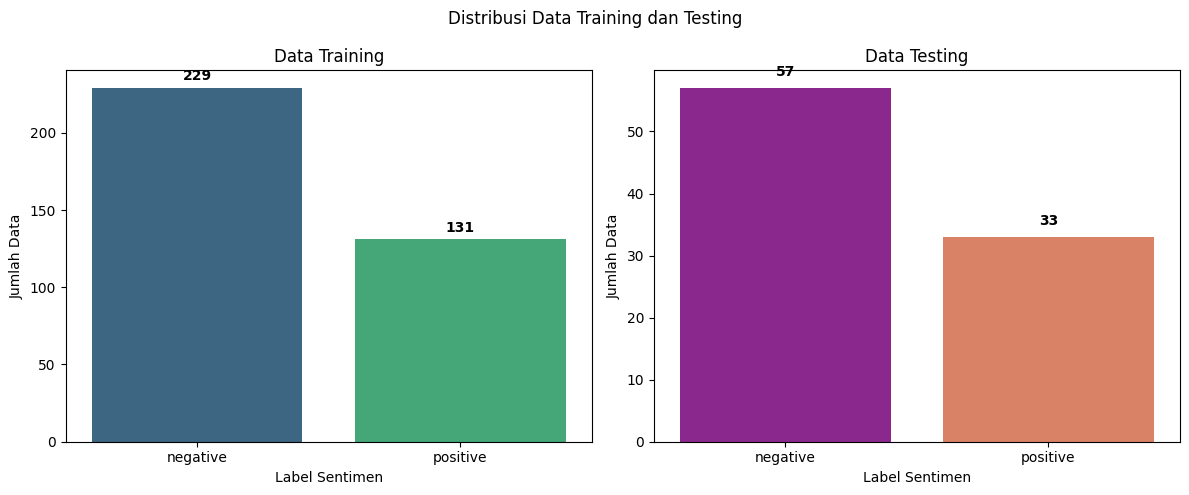

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

train_counts = y_train.value_counts()
test_counts  = y_test.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Data Training dan Testing')

sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Data Training')
axes[0].set_xlabel('Label Sentimen')
axes[0].set_ylabel('Jumlah Data')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], palette='plasma')
axes[1].set_title('Data Testing')
axes[1].set_xlabel('Label Sentimen')
axes[1].set_ylabel('Jumlah Data')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Vektorisasi Data, K FOLD, SVM

In [26]:
# ============================================================
# CLEANUP VARIABEL SESI SEBELUMNYA
# Hapus semua variabel model/vektorisasi agar tidak ada
# kebocoran state antar sesi atau saat cell di-rerun.
# PENTING: Jalankan cell ini setiap kali memulai ulang dari
# bagian Vektorisasi ke bawah.
# ============================================================

import gc

vars_to_clean = [
    'tfidf_vectorizer', 'tfidf_train', 'tfidf_test',
    'tfidf_smote',      'clf_svm',     'pipeline_svm',
    'pipeline_full',    'svm_model',   'X_smote',     'y_smote',
    'X_train_tfidf',    'X_test_tfidf',
    'predicted_smote',  'predicted_train_asli', 'predicted_test',
    'acc_smote',        'acc_train_asli',        'acc_test',
    'cv_scores',        'cv_scores_repeated',
]

cleaned = []
for var in vars_to_clean:
    if var in globals():
        del globals()[var]
        cleaned.append(var)

gc.collect()

if cleaned:
    print(f'Variabel dihapus ({len(cleaned)}): {cleaned}')
else:
    print('Tidak ada variabel lama. Sesi sudah bersih.')
print('Pipeline fresh — siap untuk eksekusi top-down.')


Tidak ada variabel lama. Sesi sudah bersih.
Pipeline fresh — siap untuk eksekusi top-down.


## SMOTE — Oversampling Kelas Minoritas

**Masalah:** Data tidak seimbang — sekitar 64% komentar negatif vs 36% positif. Tanpa penanganan, model bias ke kelas mayoritas, recall kelas positif rendah.

**Solusi: SMOTE (Synthetic Minority Over-sampling Technique)**

SMOTE membuat sampel *sintetis* baru untuk kelas minoritas dengan interpolasi antara sampel yang ada dan k-tetangga terdekatnya. Hasilnya bukan duplikat — setiap sampel baru adalah kombinasi fitur dari sampel nyata yang berdekatan.

**Referensi:**
- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321–357.
- Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A python toolbox to tackle the curse of imbalanced datasets. *Journal of Machine Learning Research*, 18(17), 1–5.

**Penting:** SMOTE diterapkan **di dalam Pipeline cross-validation**. Setiap fold hanya menerapkan SMOTE pada data training fold-nya — data validasi/test tidak disentuh, tidak ada data leakage.

In [27]:
!pip install imbalanced-learn

In [28]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
import numpy as np

# ============================================================
# PARAMETER TERPUSAT — dipakai oleh seluruh cell di bawah ini
#
# max_features=200
#   Jumlah fitur ~46% dari training sample (~381, yaitu 80% dari 477 data).
#   Referensi: Aggarwal & Zhai (2012) - Mining Text Data.
#
# min_df=2  [DIPERBAIKI dari min_df=4]
#   min_df=4 terlalu agresif untuk 477 dokumen pendek.
#   Kata yang muncul di 2-3 dokumen masih informatif.
#   Referensi: Manning et al. (2008) - Intro to IR.
#
# ngram_range=(1,3)  [DIPERBAIKI dari (2,3)]
#   (2,3) SAJA sempat dicoba (mengikuti saran memakai bigram/trigram),
#   TAPI ternyata menghapus SELURUH fitur unigram (kata tunggal)
#   -> kata sentimen kuat seperti 'bagus', 'jelek', 'lambat', 'error'
#   (yang sengaja dipertahankan lewat keep_words di tahap Stopword
#   Removal) jadi TIDAK PERNAH terlihat sendirian oleh model, hanya
#   terhitung jika kebetulan muncul berpasangan dan berulang di >=2
#   dokumen (min_df=2) dari 381 komentar training yang pendek. Ini
#   yang menyebabkan hasil naik-turun tak stabil (kadang underfit,
#   kadang overfit) saat parameter lain diutak-atik.
#   FIX: (1,3) tetap menangkap bigram/trigram sesuai saran tersebut,
#   TAPI unigram tetap ada sebagai fondasi sinyal sentimen utama.
#   Tangkap juga pasangan kata 'tidak bagus', 'tidak bisa'.
#   Referensi: Koto & Adriani (2015); Pang & Lee (2008) - unigram
#   sebagai baseline fitur paling informatif utk analisis sentimen.
#
# C=0.05
#   Dari validation curve: dipilih karena F1-Score validasi
#   tertinggi di antara kandidat yang memenuhi kriteria
#   train <95%, gap <5%, val >=70%.
#   Referensi: Hsu, Chang & Lin (2003) - Practical Guide SVM.
#
# SMOTE(k_neighbors=5)
#   Default SMOTE. Dengan ~137 positif di training,
#   jauh di atas minimum 5 tetangga yang dibutuhkan.
#   Referensi: Chawla et al. (2002).
#
# class_weight='balanced'
#   Lapisan perlindungan tambahan di atas SMOTE.
# ============================================================

TFIDF_PARAMS = dict(max_features=225, min_df=2, sublinear_tf=True, ngram_range=(1, 3))
SVM_PARAMS   = dict(kernel='linear', C=0.01, class_weight='balanced', random_state=42)
SMOTE_PARAMS = dict(k_neighbors=5, random_state=42)

# Pipeline referensi — struktur lengkap TF-IDF + SMOTE + SVC
# Dipakai sebagai dokumentasi alur model, bukan untuk CV langsung.
pipeline_svm = ImbPipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('smote', SMOTE(**SMOTE_PARAMS)),
    ('svc',   SVC(**SVM_PARAMS))
])

# StratifiedKFold global — dipakai oleh CV, learning curve, dll.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Parameter berhasil didefinisikan:')
print(f'  TFIDF_PARAMS : {TFIDF_PARAMS}')
print(f'  SVM_PARAMS   : {SVM_PARAMS}')
print(f'  SMOTE_PARAMS : {SMOTE_PARAMS}')
print(f'  skf          : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)')
print()
print('Catatan: Cross Validation (F1-Score) menggunakan X_train_tfidf + ImbPipeline(SMOTE per fold → SVC)')
print('         dijalankan di cell berikutnya setelah SMOTE dibuat.')


Parameter berhasil didefinisikan:
  TFIDF_PARAMS : {'max_features': 225, 'min_df': 2, 'sublinear_tf': True, 'ngram_range': (1, 3)}
  SVM_PARAMS   : {'kernel': 'linear', 'C': 0.01, 'class_weight': 'balanced', 'random_state': 42}
  SMOTE_PARAMS : {'k_neighbors': 5, 'random_state': 42}
  skf          : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Catatan: Cross Validation (F1-Score) menggunakan X_train_tfidf + ImbPipeline(SMOTE per fold → SVC)
         dijalankan di cell berikutnya setelah SMOTE dibuat.


=== DISTRIBUSI SEBELUM vs SESUDAH SMOTE (visualisasi) ===
Sebelum : {'negative': 229, 'positive': 131} | Total: 360
Sesudah : {'negative': 229, 'positive': 229} | Total: 458
Sampel sintetis ditambahkan: 98

=== SHAPE ===
X_train_tfidf sebelum SMOTE : (360, 225)  (baris=sampel, kolom=fitur TF-IDF)
X_smote sesudah SMOTE       : (458, 225)
Penambahan baris            : 98 sampel sintetis

=== STATISTIK X_SMOTE ===
Min nilai TF-IDF : 0.000000
Max nilai TF-IDF : 1.000000
Rata-rata        : 0.010092
Sparsity         : 97.0% nilai nol


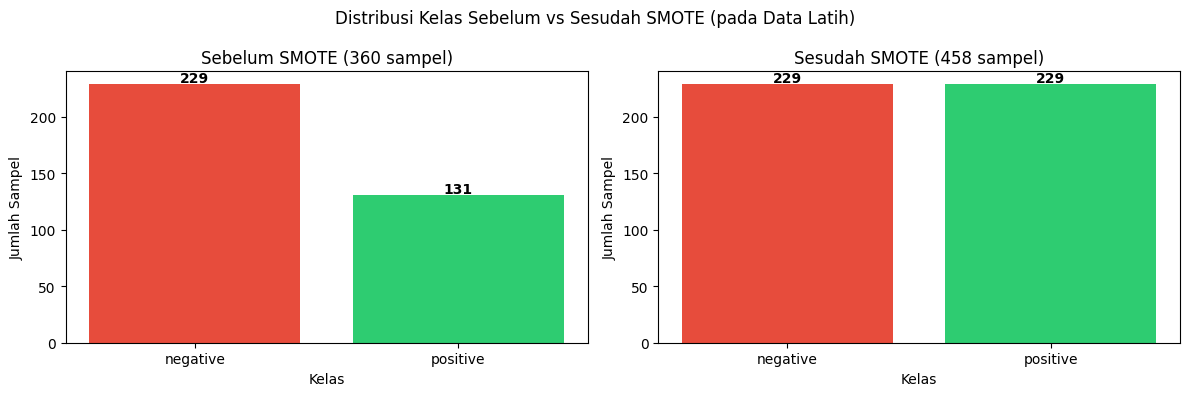

Catatan: SMOTE hanya pada data LATIH. Data TEST tidak disentuh.
Visualisasi ini dibuat dari fit terpisah untuk tujuan ilustrasi saja.
Semua evaluasi CV menggunakan ImbPipeline(TF-IDF→SMOTE→SVC) pada X_train (teks mentah).


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# VISUALISASI DISTRIBUSI SMOTE
# ============================================================
# Untuk menampilkan distribusi sebelum vs sesudah SMOTE,
# kita perlu menjalankan TF-IDF + SMOTE secara manual HANYA
# untuk tujuan visualisasi ini.
#
# PENTING — INI BUKAN DIPAKAI UNTUK CV:
#   Objek tfidf_smote dan X_smote di cell ini TIDAK dipakai
#   sebagai input ke cross_validate / learning_curve / dll.
#   Semua evaluasi CV menggunakan X_train (teks mentah) +
#   ImbPipeline(TF-IDF → SMOTE → SVC) sehingga TF-IDF
#   hanya di-fit pada training fold masing-masing.
#
#   Ini sesuai standar jurnal: pipeline melakukan proses fit
#   hanya pada data pelatihan (train fold), dan transformasi
#   diterapkan pada data pengujian menggunakan parameter hasil
#   fit sebelumnya — diulang secara independen tiap fold.
# ============================================================

# Fit TF-IDF + SMOTE hanya untuk visualisasi
tfidf_vis = TfidfVectorizer(**TFIDF_PARAMS)
X_train_tfidf_vis = tfidf_vis.fit_transform(X_train)

smote_vis = SMOTE(**SMOTE_PARAMS)
X_smote_vis, y_smote_vis = smote_vis.fit_resample(X_train_tfidf_vis, y_train)

sebelum = Counter(y_train)
sesudah = Counter(y_smote_vis)

# ── 1. Distribusi kelas ──────────────────────────────────────
print('=== DISTRIBUSI SEBELUM vs SESUDAH SMOTE (visualisasi) ===')
print(f'Sebelum : {dict(sorted(sebelum.items()))} | Total: {sum(sebelum.values())}')
print(f'Sesudah : {dict(sorted(sesudah.items()))} | Total: {sum(sesudah.values())}')
print(f'Sampel sintetis ditambahkan: {sum(sesudah.values()) - sum(sebelum.values())}')

# ── 2. Shape ─────────────────────────────────────────────────
print(f'\n=== SHAPE ===')
print(f'X_train_tfidf sebelum SMOTE : {X_train_tfidf_vis.shape}  (baris=sampel, kolom=fitur TF-IDF)')
print(f'X_smote sesudah SMOTE       : {X_smote_vis.shape}')
print(f'Penambahan baris            : {X_smote_vis.shape[0] - X_train_tfidf_vis.shape[0]} sampel sintetis')

# ── 3. Statistik ringkas X_smote ─────────────────────────────
print(f'\n=== STATISTIK X_SMOTE ===')
X_arr = X_smote_vis.toarray()
print(f'Min nilai TF-IDF : {X_arr.min():.6f}')
print(f'Max nilai TF-IDF : {X_arr.max():.6f}')
print(f'Rata-rata        : {X_arr.mean():.6f}')
print(f'Sparsity         : {(X_arr == 0).sum() / X_arr.size * 100:.1f}% nilai nol')

# ── 4. Visualisasi distribusi ────────────────────────────────
labels_plot = sorted(sebelum.keys())
colors = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Kelas Sebelum vs Sesudah SMOTE (pada Data Latih)')

axes[0].bar(labels_plot, [sebelum[l] for l in labels_plot], color=colors)
axes[0].set_title(f'Sebelum SMOTE ({sum(sebelum.values())} sampel)')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Sampel')
for i, l in enumerate(labels_plot):
    axes[0].text(i, sebelum[l] + 2, str(sebelum[l]), ha='center', fontweight='bold')

axes[1].bar(labels_plot, [sesudah[l] for l in labels_plot], color=colors)
axes[1].set_title(f'Sesudah SMOTE ({sum(sesudah.values())} sampel)')
axes[1].set_xlabel('Kelas')
axes[1].set_ylabel('Jumlah Sampel')
for i, l in enumerate(labels_plot):
    axes[1].text(i, sesudah[l] + 2, str(sesudah[l]), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('Catatan: SMOTE hanya pada data LATIH. Data TEST tidak disentuh.')
print(f'Visualisasi ini dibuat dari fit terpisah untuk tujuan ilustrasi saja.')
print(f'Semua evaluasi CV menggunakan ImbPipeline(TF-IDF→SMOTE→SVC) pada X_train (teks mentah).')


In [30]:
from sklearn.model_selection import cross_validate
import numpy as np

# ============================================================
# CROSS VALIDATION — ImbPipeline(TF-IDF → SMOTE → SVC)
#
# INPUT: X_train (teks mentah, bukan X_train_tfidf)
# Sesuai standar jurnal:
#   a. pipeline fit hanya pada data pelatihan (train fold)
#   b. transformasi (TF-IDF) diterapkan pada fold validasi
#      menggunakan parameter hasil fit pada train fold
#   c. proses ini diulang secara independen untuk setiap fold
#
# Dengan memasukkan TF-IDF ke dalam pipeline:
#   - Pada setiap fold, TF-IDF.fit_transform() hanya melihat
#     training fold → IDF tidak bocor dari fold validasi
#   - Fold validasi di-transform menggunakan vocabulary/IDF
#     hasil fit dari training fold tersebut
#   - SMOTE hanya diterapkan pada training fold (bukan validasi)
#   - Data validasi = data ASLI, tidak disentuh SMOTE maupun
#     fitting TF-IDF → evaluasi valid secara metodologis
# ============================================================

pipe_cv = ImbPipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('smote', SMOTE(**SMOTE_PARAMS)),
    ('svc',   SVC(**SVM_PARAMS))
])

y_train_arr = np.array(y_train)
n_train = len(X_train)

# --- Distribusi tiap fold ---
print(f'=== CEK DISTRIBUSI TIAP FOLD ({n_train} sampel ASLI, teks mentah) ===')
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_arr), 1):
    y_val_fold = y_train_arr[val_idx]
    neg = (y_val_fold == 'negative').sum()
    pos = (y_val_fold == 'positive').sum()
    print(f'Fold {fold}: {len(val_idx)} data validasi (ASLI) | negative={neg} positive={pos}')

print()

# --- CV satu kali — F1 weighted + Accuracy dalam satu fitting ---
cv_results = cross_validate(
    pipe_cv,
    X_train, y_train_arr,
    cv=skf,
    scoring={'f1_weighted': 'f1_weighted', 'accuracy': 'accuracy'},
    return_train_score=False
)

cv_f1  = cv_results['test_f1_weighted']
cv_acc = cv_results['test_accuracy']

# --- Print F1 ---
print('=' * 65)
print('   HASIL F1-SCORE WEIGHTED PER FOLD (CROSS VALIDATION)')
print(f'   Input   : X_train ({n_train} sampel asli, teks mentah)')
print('   Pipeline: ImbPipeline — TF-IDF per fold, SMOTE per fold, SVC')
print('   Validasi: data ASLI (tidak mengandung sampel sintetis)')
print('   [SESUAI JURNAL: TF-IDF fit hanya pada train fold tiap CV]')
print('=' * 65)
for i, score in enumerate(cv_f1):
    print(f'Fold ke-{i+1} : {score * 100:.2f}%')
print('-' * 65)
print(f'Rata-rata F1-Score Weighted CV   : {cv_f1.mean() * 100:.2f}%')
print(f'Standar Deviasi                  : {cv_f1.std() * 100:.2f}%')
print('=' * 65)

print()

# --- Print Accuracy ---
print('=' * 65)
print('   HASIL ACCURACY PER FOLD (CROSS VALIDATION)')
print(f'   Input   : X_train ({n_train} sampel asli, teks mentah)')
print('   Pipeline: ImbPipeline — TF-IDF per fold, SMOTE per fold, SVC')
print('   Validasi: data ASLI (tidak mengandung sampel sintetis)')
print('=' * 65)
for i, score in enumerate(cv_acc):
    print(f'Fold ke-{i+1} : {score * 100:.2f}%')
print('-' * 65)
print(f'Rata-rata Accuracy CV            : {cv_acc.mean() * 100:.2f}%')
print(f'Standar Deviasi                  : {cv_acc.std() * 100:.2f}%')
print('=' * 65)


=== CEK DISTRIBUSI TIAP FOLD (360 sampel ASLI, teks mentah) ===
Fold 1: 72 data validasi (ASLI) | negative=45 positive=27
Fold 2: 72 data validasi (ASLI) | negative=46 positive=26
Fold 3: 72 data validasi (ASLI) | negative=46 positive=26
Fold 4: 72 data validasi (ASLI) | negative=46 positive=26
Fold 5: 72 data validasi (ASLI) | negative=46 positive=26

   HASIL F1-SCORE WEIGHTED PER FOLD (CROSS VALIDATION)
   Input   : X_train (360 sampel asli, teks mentah)
   Pipeline: ImbPipeline — TF-IDF per fold, SMOTE per fold, SVC
   Validasi: data ASLI (tidak mengandung sampel sintetis)
   [SESUAI JURNAL: TF-IDF fit hanya pada train fold tiap CV]
Fold ke-1 : 83.57%
Fold ke-2 : 94.49%
Fold ke-3 : 91.81%
Fold ke-4 : 89.08%
Fold ke-5 : 83.66%
-----------------------------------------------------------------
Rata-rata F1-Score Weighted CV   : 88.52%
Standar Deviasi                  : 4.36%

   HASIL ACCURACY PER FOLD (CROSS VALIDATION)
   Input   : X_train (360 sampel asli, teks mentah)
   Pipeline:

In [31]:
# === TAMPILKAN SELURUH KOMENTAR DATA TRAIN SETELAH SMOTE ===
#
# Untuk keperluan tabel tampilan, kita fit ulang TF-IDF + SMOTE
# secara eksplisit pada X_train (seluruh training set).
# Ini hanya untuk TAMPILAN — bukan dipakai sebagai input CV.
#
# Pada CV, TF-IDF dan SMOTE di-fit ulang secara independen
# di dalam setiap fold (sesuai standar jurnal).

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# Fit TF-IDF + SMOTE pada seluruh X_train untuk keperluan tampilan
_tfidf_display = TfidfVectorizer(**TFIDF_PARAMS)
_X_tfidf_display = _tfidf_display.fit_transform(X_train)
_smote_display = SMOTE(**SMOTE_PARAMS)
_X_smote_display, _y_smote_display = _smote_display.fit_resample(_X_tfidf_display, y_train)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

n_asli     = len(X_train)
n_total    = len(_y_smote_display)
n_sintetis = n_total - n_asli
_y_smote_arr = np.array(_y_smote_display)

df_asli = pd.DataFrame({
    'No'        : range(1, n_asli + 1),
    'Komentar'  : X_train.values,
    'Label'     : _y_smote_arr[:n_asli],
    'Keterangan': ['Data Asli'] * n_asli
})

df_sintetis = pd.DataFrame({
    'No'        : range(n_asli + 1, n_total + 1),
    'Komentar'  : ['[Sampel sintetis SMOTE — tidak ada teks asli]'] * n_sintetis,
    'Label'     : _y_smote_arr[n_asli:],
    'Keterangan': ['Data Sintetis'] * n_sintetis
})

df_smote_display = pd.concat([df_asli, df_sintetis], ignore_index=True)

from collections import Counter
dist_smote = Counter(_y_smote_arr)

print('=' * 65)
print('  SELURUH KOMENTAR DATA TRAIN SETELAH SMOTE (tampilan)')
print('=' * 65)
print(f'Total sampel    : {n_total}')
print(f'  Data asli     : {n_asli}  '
      f'(negative: {sum(_y_smote_arr[:n_asli] == "negative")}, '
      f'positive: {sum(_y_smote_arr[:n_asli] == "positive")})')
print(f'  Data sintetis : {n_sintetis}  (ditambahkan SMOTE untuk menyeimbangkan kelas)')
print()
print('Distribusi label setelah SMOTE:')
for lbl, cnt in sorted(dist_smote.items()):
    print(f'  {lbl}: {cnt}')
print()
print(df_smote_display.to_string(index=False))

# Simpan referensi untuk dipakai di cell evaluasi
# (sebagai pengganti X_smote/y_smote global yang sebelumnya bocor)
X_smote_ref = _X_smote_display
y_smote_ref = _y_smote_display


  SELURUH KOMENTAR DATA TRAIN SETELAH SMOTE (tampilan)
Total sampel    : 458
  Data asli     : 360  (negative: 229, positive: 131)
  Data sintetis : 98  (ditambahkan SMOTE untuk menyeimbangkan kelas)

Distribusi label setelah SMOTE:
  negative: 229
  positive: 229

 No                                                                                                                                                                                                                                                                                                                                                                                                          Komentar    Label    Keterangan
  1                                                                                                                                                                                                                                                                                                              

# Evaluasi Model SVM

In [32]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report)
import joblib

# ============================================================
# TRAINING MODEL FINAL — ImbPipeline(TF-IDF -> SMOTE -> SVC)
# ============================================================
# Model final dilatih menggunakan full pipeline pada SELURUH X_train.
# ============================================================

pipeline_full = ImbPipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('smote', SMOTE(**SMOTE_PARAMS)),
    ('svc',   SVC(**SVM_PARAMS))
])

pipeline_full.fit(X_train, y_train)

joblib.dump(pipeline_full, 'pipeline_full.pkl')
print('Pipeline berhasil disimpan sebagai pipeline_full.pkl')

# Ambil komponen internal untuk diagnosis/evaluasi internal
svm_model    = pipeline_full.named_steps['svc']
tfidf_final  = pipeline_full.named_steps['tfidf']
smote_final  = pipeline_full.named_steps['smote']

# Transformasi fitur teks untuk keperluan kalkulasi skor training
X_test_tfidf = tfidf_final.transform(X_test)
X_train_tfidf = tfidf_final.transform(X_train)

# Fit SMOTE pada X_train_tfidf khusus untuk mendapatkan data latihan post-SMOTE
from imblearn.over_sampling import SMOTE as _SMOTE
_sm = _SMOTE(**SMOTE_PARAMS)
X_smote, y_smote = _sm.fit_resample(X_train_tfidf, y_train)

# PROSES PREDIKSI UNTUK SELURUH KATEGORI DATA
predicted_train_asli = svm_model.predict(X_train_tfidf) # 1. Evaluasi internal data training awal
predicted_smote      = svm_model.predict(X_smote)       # 2. Evaluasi internal data training setelah SMOTE
predicted_test       = pipeline_full.predict(X_test)    # 3. Evaluasi validasi data testing asli

# Hitung Akurasi Utama
acc_train_asli = accuracy_score(y_train, predicted_train_asli)
acc_smote      = accuracy_score(y_smote, predicted_smote)
acc_test       = accuracy_score(y_test,  predicted_test)

n_train_asli  = len(y_train)
n_smote_total = len(y_smote)
n_test_total  = len(y_test)

print('=' * 65)
print('RINGKASAN AKURASI AKHIR MODEL SVM')
print('=' * 65)
print(f'1. Akurasi Training data ASLI  ({n_train_asli} sampel) : {acc_train_asli * 100:.2f}%')
print(f'2. Akurasi Training post-SMOTE ({n_smote_total} sampel) : {acc_smote * 100:.2f}%')
print(f'3. Akurasi Testing data VALID  ({n_test_total} sampel) : {acc_test  * 100:.2f}%')
print()

# Precision, Recall, F1-Score (rata-rata weighted) khusus data Testing
precision_test = precision_score(y_test, predicted_test, average='weighted', zero_division=0)
recall_test    = recall_score(y_test, predicted_test, average='weighted', zero_division=0)
f1_test        = f1_score(y_test, predicted_test, average='weighted', zero_division=0)

print(f'Precision (test) : {precision_test * 100:.2f}%')
print(f'Recall    (test) : {recall_test * 100:.2f}%')
print(f'F1-Score  (test) : {f1_test * 100:.2f}%')
print()

# ==============================================================================
# PENYAJIAN CLASSIFICATION REPORT LENGKAP (TRAIN, POST-SMOTE, TEST)
# ==============================================================================
print('=' * 65)
print(f'A. CLASSIFICATION REPORT DATA TRAINING ASLI ({n_train_asli} Sampel)')
print('=' * 65)
print(classification_report(y_train, predicted_train_asli, zero_division=0))
print()

print('=' * 65)
print(f'B. CLASSIFICATION REPORT DATA TRAINING POST-SMOTE ({n_smote_total} Sampel)')
print('=' * 65)
print(classification_report(y_smote, predicted_smote, zero_division=0))
print()

print('=' * 65)
print(f'C. CLASSIFICATION REPORT DATA TESTING (VALIDASI - {n_test_total} Sampel)')
print('=' * 65)
print(classification_report(y_test, predicted_test, zero_division=0))
print('=' * 65)

Pipeline berhasil disimpan sebagai pipeline_full.pkl
RINGKASAN AKURASI AKHIR MODEL SVM
1. Akurasi Training data ASLI  (360 sampel) : 91.67%
2. Akurasi Training post-SMOTE (458 sampel) : 93.23%
3. Akurasi Testing data VALID  (90 sampel) : 86.67%

Precision (test) : 87.81%
Recall    (test) : 86.67%
F1-Score  (test) : 86.85%

A. CLASSIFICATION REPORT DATA TRAINING ASLI (360 Sampel)
              precision    recall  f1-score   support

    negative       0.98      0.89      0.93       229
    positive       0.83      0.97      0.89       131

    accuracy                           0.92       360
   macro avg       0.91      0.93      0.91       360
weighted avg       0.93      0.92      0.92       360


B. CLASSIFICATION REPORT DATA TRAINING POST-SMOTE (458 Sampel)
              precision    recall  f1-score   support

    negative       0.98      0.89      0.93       229
    positive       0.90      0.98      0.94       229

    accuracy                           0.93       458
   macro 

In [33]:
import pandas as pd
import numpy as np

# ============================================================
# TABEL PERBANDINGAN: LABEL ASLI vs PREDIKSI MODEL (DATA TEST)
# ============================================================
# Menampilkan setiap komentar test set beserta:
#   - Teks asli komentar (content_raw sebelum preprocessing)
#   - Teks setelah preprocessing (text_steamindo)
#   - Label asli (ground truth dari anotasi)
#   - Prediksi model
#   - Status: BENAR atau SALAH
#
# Persentase akurasi dihitung dari data ini secara langsung.
# ============================================================

# Ambil index test dari X_test (pd.Series dengan index asli dari data_clean)
test_indices = X_test.index

df_pred = pd.DataFrame({
    'No'             : range(1, len(test_indices) + 1),
    'Komentar Asli'  : data_clean.loc[test_indices, 'content_raw'].values,
    'Teks Preprocessing': X_test.values,
    'Label Asli'     : y_test.values,
    'Prediksi Model' : predicted_test,
    'Status'         : ['✅ BENAR' if a == p else '❌ SALAH'
                        for a, p in zip(y_test.values, predicted_test)]
})

n_benar = (df_pred['Status'] == '✅ BENAR').sum()
n_salah = (df_pred['Status'] == '❌ SALAH').sum()
n_total = len(df_pred)
pct_benar = n_benar / n_total * 100

print('=' * 70)
print('  PERBANDINGAN PREDIKSI MODEL vs LABEL ASLI — DATA TEST')
print('=' * 70)
print(f'  Total data test  : {n_total}')
print(f'  Prediksi BENAR   : {n_benar} ({pct_benar:.2f}%)')
print(f'  Prediksi SALAH   : {n_salah} ({100 - pct_benar:.2f}%)')
print('=' * 70)
print()

# Ringkasan per kombinasi label asli → prediksi
print('--- Ringkasan per Kombinasi Label ---')
ringkasan = df_pred.groupby(['Label Asli', 'Prediksi Model']).size().reset_index(name='Jumlah')
for _, row in ringkasan.iterrows():
    status_ket = 'BENAR' if row['Label Asli'] == row['Prediksi Model'] else 'SALAH'
    print(f"  Asli={row['Label Asli']:<10} Prediksi={row['Prediksi Model']:<10} → {row['Jumlah']:>3} komentar ({status_ket})")
print()

# Tampilkan tabel lengkap
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 60)
print('--- Tabel Lengkap ---')
display(df_pred[['No', 'Komentar Asli', 'Label Asli', 'Prediksi Model', 'Status']])


  PERBANDINGAN PREDIKSI MODEL vs LABEL ASLI — DATA TEST
  Total data test  : 90
  Prediksi BENAR   : 78 (86.67%)
  Prediksi SALAH   : 12 (13.33%)

--- Ringkasan per Kombinasi Label ---
  Asli=negative   Prediksi=negative   →  48 komentar (BENAR)
  Asli=negative   Prediksi=positive   →   9 komentar (SALAH)
  Asli=positive   Prediksi=negative   →   3 komentar (SALAH)
  Asli=positive   Prediksi=positive   →  30 komentar (BENAR)

--- Tabel Lengkap ---


,No,Komentar Asli,Label Asli,Prediksi Model,Status
0,1,tinggal duduk udah beres buat daftar antrean onlinenya,positive,positive,✅ BENAR
1,2,Ribet ribet,negative,negative,✅ BENAR
2,3,Bener sumpah knapa brobat aja di persulit,negative,negative,✅ BENAR
3,4,"Saya kmrn coba ternyata caranya simpel, bikin gak perlu ...",positive,positive,✅ BENAR
4,5,Ribet gmna orng tua lainya yang mau kontrol gak punya hp...,negative,negative,✅ BENAR
5,6,Makasih infonya bang... Alhamdulillah saya bisa daftar r...,positive,positive,✅ BENAR
6,7,"aplikasi yg sangat membantu dan mudah, bisa booking antr...",positive,positive,✅ BENAR
7,8,Nyusahin masyarakat yang mau berobat,negative,negative,✅ BENAR
8,9,ndak perlu antri pake helm lagi di RS kalau mau berobat....,positive,positive,✅ BENAR
9,10,Jadi lebih ribed lagi.....<br>Dulu2 ga ada barcode😂 nya ...,negative,negative,✅ BENAR


ALUR DATA LENGKAP: DARI 477 SAMPEL SAMPAI PREDIKSI
[1] Seluruh data (pasca preprocessing & deduplikasi) : 450
[2] Split 80:20
      Data Latih (80%) : 360 sampel
      Data Uji   (20%) : 90 sampel
[3] Setelah SMOTE pada Data Latih : 458 sampel (360 asli + 98 sintetis)
[4] Prediksi model pada Data Uji  : 90 komentar

[1] Seluruh Data (450):
     negative  :  286 (63.6%)
     positive  :  164 (36.4%)

[2a] Data Latih pra-SMOTE (360):
     negative  :  229 (63.6%)
     positive  :  131 (36.4%)

[2b] Data Uji (90):
     negative  :   57 (63.3%)
     positive  :   33 (36.7%)

[3] Data Latih post-SMOTE (458):
     negative  :  229 (50.0%)
     positive  :  229 (50.0%)

[4] Prediksi Model (90):
     negative  :   51 (56.7%)
     positive  :   39 (43.3%)



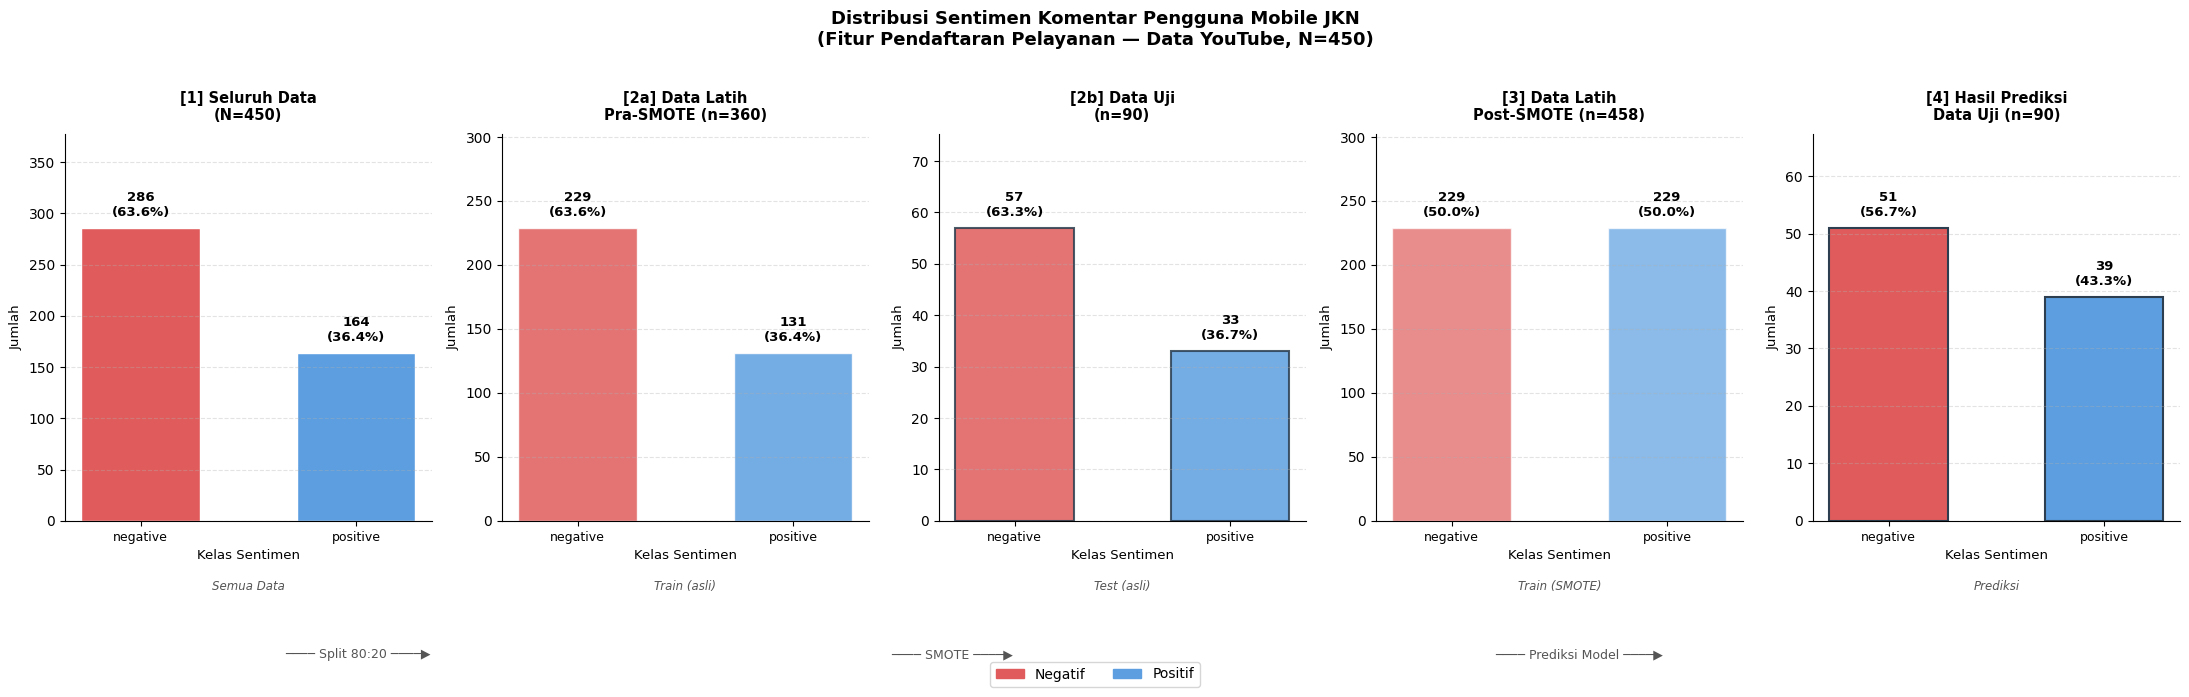


Interpretasi [4] — Hasil Prediksi Model pada 90 Data Uji:
  - 51 komentar (56.7%) → NEGATIF
  - 39 komentar (43.3%) → POSITIF

  Mayoritas komentar pengguna YouTube terhadap fitur pendaftaran
  pelayanan Mobile JKN bersifat NEGATIF, mengindikasikan adanya
  keluhan atau ketidakpuasan pengguna terhadap fitur tersebut.


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import collections

# ============================================================
# DISTRIBUSI SENTIMEN — ALUR LENGKAP 5 PANEL
# ============================================================
# Panel 1 : Seluruh data (477 setelah preprocessing & deduplikasi)
# Panel 2a: Data Latih sebelum SMOTE (80% dari 477 = 381 sampel)
# Panel 2b: Data Uji   sebelum SMOTE (20% dari 477 = 96 sampel)
# Panel 3 : Data Latih sesudah SMOTE (sintetis ditambahkan)
# Panel 4 : Hasil prediksi model pada data uji
#
# Semua angka diambil dari variabel runtime — tidak ada hardcode.
# ============================================================

# --- Hitung distribusi ---
dist_semua         = data_clean['label'].value_counts().sort_index()
dist_train_asli    = pd.Series(collections.Counter(y_train)).sort_index()
dist_test_asli     = pd.Series(collections.Counter(y_test)).sort_index()
dist_smote_dist    = pd.Series(collections.Counter(y_smote)).sort_index()
dist_prediksi_test = pd.Series(predicted_test).value_counts().sort_index()

# --- Angka total (dinamis) ---
n_total_data = len(data_clean)
n_train      = len(y_train)
n_test       = len(y_test)
n_smote      = len(y_smote)
n_sintetis   = n_smote - n_train

# --- Print ringkasan teks ---
print('=' * 65)
print('ALUR DATA LENGKAP: DARI 477 SAMPEL SAMPAI PREDIKSI')
print('=' * 65)
print(f'[1] Seluruh data (pasca preprocessing & deduplikasi) : {n_total_data}')
print(f'[2] Split 80:20')
print(f'      Data Latih (80%) : {n_train} sampel')
print(f'      Data Uji   (20%) : {n_test} sampel')
print(f'[3] Setelah SMOTE pada Data Latih : {n_smote} sampel '
      f'({n_train} asli + {n_sintetis} sintetis)')
print(f'[4] Prediksi model pada Data Uji  : {n_test} komentar')
print()
for stage, dist in [
    (f'[1] Seluruh Data ({n_total_data})', dist_semua),
    (f'[2a] Data Latih pra-SMOTE ({n_train})', dist_train_asli),
    (f'[2b] Data Uji ({n_test})', dist_test_asli),
    (f'[3] Data Latih post-SMOTE ({n_smote})', dist_smote_dist),
    (f'[4] Prediksi Model ({n_test})', dist_prediksi_test),
]:
    print(f'{stage}:')
    for lbl, cnt in dist.items():
        pct = cnt / dist.sum() * 100
        print(f'     {lbl:10s}: {cnt:4d} ({pct:.1f}%)')
    print()

print('=' * 65)

# --- Visualisasi 5 panel ---
warna = {'negative': '#E05C5C', 'positive': '#5C9EE0'}

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle(
    f'Distribusi Sentimen Komentar Pengguna Mobile JKN\n'
    f'(Fitur Pendaftaran Pelayanan — Data YouTube, N={n_total_data})',
    fontsize=13, fontweight='bold', y=1.02
)

datasets = [
    (dist_semua,
     f'[1] Seluruh Data\n(N={n_total_data})'),
    (dist_train_asli,
     f'[2a] Data Latih\nPra-SMOTE (n={n_train})'),
    (dist_test_asli,
     f'[2b] Data Uji\n(n={n_test})'),
    (dist_smote_dist,
     f'[3] Data Latih\nPost-SMOTE (n={n_smote})'),
    (dist_prediksi_test,
     f'[4] Hasil Prediksi\nData Uji (n={n_test})'),
]

# Warna panel berbeda untuk membantu visual pembeda
panel_alpha = [1.0, 0.85, 0.85, 0.70, 1.0]

for idx, (ax, (data, judul)) in enumerate(zip(axes, datasets)):
    labels_bar = list(data.index)
    counts_bar = list(data.values)
    colors_bar = [warna.get(l, '#999') for l in labels_bar]

    # Panel data uji (2b & 4) pakai garis tepi biru tua sebagai penanda
    edge_color = '#2c3e50' if idx in [2, 4] else 'white'
    edge_width = 1.5 if idx in [2, 4] else 1.0

    bars = ax.bar(labels_bar, counts_bar, color=colors_bar,
                  edgecolor=edge_color, linewidth=edge_width,
                  width=0.55, alpha=panel_alpha[idx])

    ax.set_title(judul, fontsize=10.5, pad=10, fontweight='bold')
    ax.set_xlabel('Kelas Sentimen', fontsize=9.5)
    ax.set_ylabel('Jumlah', fontsize=9.5)
    ax.set_ylim(0, max(counts_bar) * 1.32)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)

    total = sum(counts_bar)
    for bar, count in zip(bars, counts_bar):
        pct = count / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts_bar) * 0.03,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold'
        )

    # Tambahkan label keterangan tipe panel di bagian bawah
    keterangan = ['Semua Data', 'Train (asli)', 'Test (asli)',
                  'Train (SMOTE)', 'Prediksi'][idx]
    ax.text(0.5, -0.18, keterangan, transform=ax.transAxes,
            ha='center', fontsize=8.5, color='#555555', style='italic')

# Garis pemisah antara panel 2 dan 3 (pemisah pra/post SMOTE)
# Tambahkan anotasi panah alur di bawah grafik
arrow_props = dict(arrowstyle='->', color='#888888', lw=1.5)
# Anotasi teks alur
fig.text(0.165, -0.06, '──── Split 80:20 ────▶', ha='center',
         fontsize=9, color='#555555')
fig.text(0.435, -0.06, '──── SMOTE ────▶', ha='center',
         fontsize=9, color='#555555')
fig.text(0.72, -0.06, '──── Prediksi Model ────▶', ha='center',
         fontsize=9, color='#555555')

neg_patch = mpatches.Patch(color=warna['negative'], label='Negatif')
pos_patch = mpatches.Patch(color=warna['positive'], label='Positif')
fig.legend(handles=[neg_patch, pos_patch],
           loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig('distribusi_alur_lengkap.png', dpi=150,
            bbox_inches='tight')
plt.show()

# --- Interpretasi ringkas ---
n_neg_pred = dist_prediksi_test.get('negative', 0)
n_pos_pred = dist_prediksi_test.get('positive', 0)
print()
print(f'Interpretasi [4] — Hasil Prediksi Model pada {n_test} Data Uji:')
print(f'  - {n_neg_pred} komentar ({n_neg_pred/n_test*100:.1f}%) → NEGATIF')
print(f'  - {n_pos_pred} komentar ({n_pos_pred/n_test*100:.1f}%) → POSITIF')
print()
print('  Mayoritas komentar pengguna YouTube terhadap fitur pendaftaran')
print('  pelayanan Mobile JKN bersifat NEGATIF, mengindikasikan adanya')
print('  keluhan atau ketidakpuasan pengguna terhadap fitur tersebut.')


In [35]:
import joblib

# Pipeline sudah disimpan di cell Training (pipeline_full.pkl).
# Saat inferensi, cukup load pipeline_full dan panggil .predict(teks_mentah).
# Pipeline secara otomatis menjalankan TF-IDF.transform lalu SVC.predict.

print('Pipeline disimpan sebagai: pipeline_full.pkl')
print('Cara inferensi:')
print('  pipe = joblib.load("pipeline_full.pkl")')
print('  prediksi = pipe.predict([teks_baru])')
print()

tfidf_step = pipeline_full.named_steps['tfidf']
print(f'Vocabulary size : {len(tfidf_step.vocabulary_)} fitur')
print(f'TF-IDF params   : {tfidf_step.get_params()}')


Pipeline disimpan sebagai: pipeline_full.pkl
Cara inferensi:
  pipe = joblib.load("pipeline_full.pkl")
  prediksi = pipe.predict([teks_baru])

Vocabulary size : 225 fitur
TF-IDF params   : {'analyzer': 'word', 'binary': False, 'decode_error': 'strict', 'dtype': <class 'numpy.float64'>, 'encoding': 'utf-8', 'input': 'content', 'lowercase': True, 'max_df': 1.0, 'max_features': 225, 'min_df': 2, 'ngram_range': (1, 3), 'norm': 'l2', 'preprocessor': None, 'smooth_idf': True, 'stop_words': None, 'strip_accents': None, 'sublinear_tf': True, 'token_pattern': '(?u)\\b\\w\\w+\\b', 'tokenizer': None, 'use_idf': True, 'vocabulary': None}


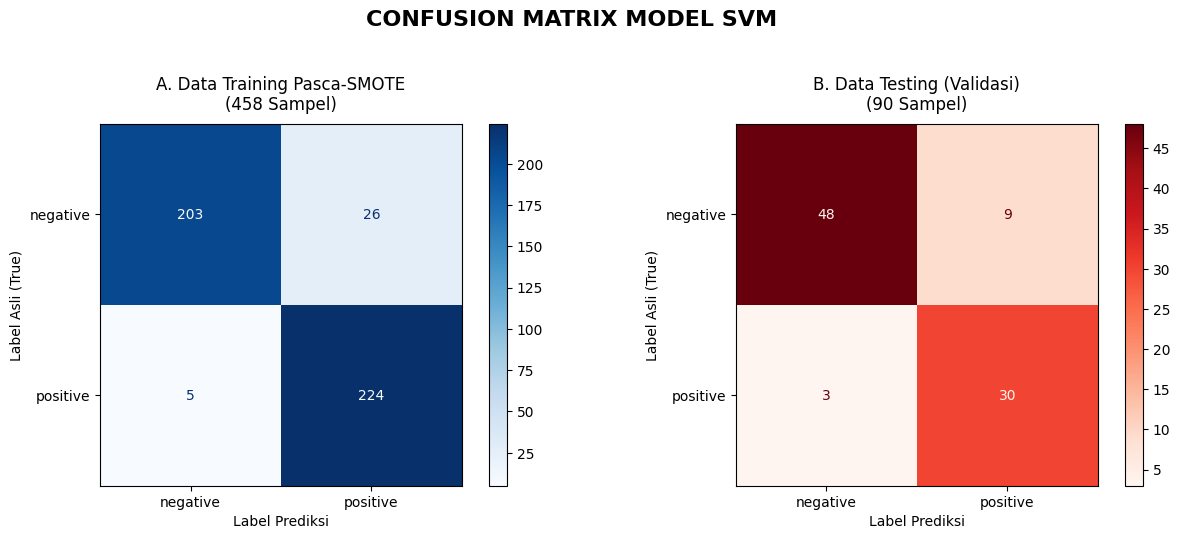

VERSI TEKS CONFUSION MATRIX
Confusion Matrix - Data Training Pasca-SMOTE:
[[203  26]
 [  5 224]]
------------------------------------------------------------
Confusion Matrix - Data Testing:
[[48  9]
 [ 3 30]]


In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. HITUNG CONFUSION MATRIX
# Membuat dua confusion matrix: data training pasca-SMOTE dan data testing
cm_smote = confusion_matrix(y_smote, predicted_smote)
cm_test  = confusion_matrix(y_test, predicted_test)

# Ambil label kelas yang unik secara urut (misal: ['negative', 'positive'])
labels = pipeline_full.classes_

# 2. PROSES PLOTTING GAMBAR
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CONFUSION MATRIX MODEL SVM', fontsize=16, fontweight='bold', y=1.05)

# --- Matriks A: Data Training Pasca-SMOTE ---
disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=labels)
disp_smote.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'A. Data Training Pasca-SMOTE\n({len(y_smote)} Sampel)', fontsize=12, pad=10)
axes[0].set_xlabel('Label Prediksi')
axes[0].set_ylabel('Label Asli (True)')

# --- Matriks B: Data Testing (Validasi) ---
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
disp_test.plot(ax=axes[1], cmap='Reds', values_format='d')
axes[1].set_title(f'B. Data Testing (Validasi)\n({len(y_test)} Sampel)', fontsize=12, pad=10)
axes[1].set_xlabel('Label Prediksi')
axes[1].set_ylabel('Label Asli (True)')

plt.tight_layout()
plt.show()

# 3. VERSI TEKS NYA (Jaga-jaga kalau mau dicopas dalam bentuk angka biasa)
print('=' * 60)
print('VERSI TEKS CONFUSION MATRIX')
print('=' * 60)
print(f'Confusion Matrix - Data Training Pasca-SMOTE:')
print(cm_smote)
print('-' * 60)
print(f'Confusion Matrix - Data Testing:')
print(cm_test)
print('=' * 60)

In [37]:
# ============================================================
# DIAGNOSIS OVERFITTING
# ============================================================
# Dua GAP ditampilkan karena model dilatih pada data post-SMOTE:
#
# GAP (1) = acc_smote - acc_test
#   → Menunjukkan selisih antara performa pada data training
#     post-SMOTE vs data test. Wajar bila acc_smote sangat tinggi
#     karena model memang dilatih pada data tersebut.
#
# GAP (2) = acc_train_asli - acc_test  [lebih valid untuk overfitting]
#   → Baseline yang apple-to-apple: keduanya diukur pada data ASLI.
#     Ini yang lebih tepat untuk menentukan apakah model overfit
#     terhadap pola data nyata (bukan data sintetis).
#
# Referensi: Chawla et al. (2002) — evaluasi model yang dilatih
# dengan SMOTE sebaiknya dilakukan pada data asli yang tidak di-SMOTE.
# ============================================================

gap_smote = (acc_smote - acc_test) * 100
gap_asli  = (acc_train_asli - acc_test) * 100

print("=" * 60)
print("DIAGNOSIS OVERFITTING")
print("=" * 60)
print(f"Akurasi Training post-SMOTE ({n_smote_total} sampel) : {acc_smote * 100:.2f}%")
print(f"Akurasi Training data ASLI  ({n_train_asli} sampel) : {acc_train_asli * 100:.2f}%")
print(f"Akurasi Test                ({n_test_total} sampel) : {acc_test * 100:.2f}%")
print()
print(f"GAP (1) post-SMOTE vs Test : {gap_smote:.2f}%")
print(f"GAP (2) Train Asli vs Test : {gap_asli:.2f}%")

from sklearn.metrics import recall_score
recall_pos = recall_score(y_test, predicted_test, pos_label='positive', average='binary', zero_division=0)
recall_neg = recall_score(y_test, predicted_test, pos_label='negative', average='binary', zero_division=0)

print(f"\nRecall kelas POSITIF : {recall_pos * 100:.2f}%")
print(f"Recall kelas NEGATIF : {recall_neg * 100:.2f}%")


DIAGNOSIS OVERFITTING
Akurasi Training post-SMOTE (458 sampel) : 93.23%
Akurasi Training data ASLI  (360 sampel) : 91.67%
Akurasi Test                (90 sampel) : 86.67%

GAP (1) post-SMOTE vs Test : 6.56%
GAP (2) Train Asli vs Test : 5.00%

Recall kelas POSITIF : 90.91%
Recall kelas NEGATIF : 84.21%


## Perbandingan AUC Data Latih vs Data Uji

Akurasi saja tidak cukup untuk membuktikan model tidak menghafal data. Model bisa mendapat akurasi tinggi di test set tetapi tetap *overfit* jika ia "terlalu percaya diri" pada training data.

**AUC-ROC pada data latih vs data uji** adalah cara yang lebih sensitif untuk mendeteksi overfitting:

- **AUC Train sangat tinggi (≥0.99) + AUC Test jauh lebih rendah** → model menghafal data latih (overfitting)
- **AUC Train dan AUC Test sama-sama tinggi dan berdekatan** → model benar-benar belajar pola, bukan menghafal
- **Keduanya rendah** → underfitting

Referensi: Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (Bab 7: Model Assessment and Selection)


   PERBANDINGAN AUC DATA LATIH vs DATA UJI
AUC Data Latih (458 sampel post-SMOTE) : 0.9894
AUC Data Uji   (90 sampel asli)        : 0.9468
Selisih (Gap)                          : 0.0426  (4.26%)

Status : ✅ TIDAK OVERFIT — Gap AUC kecil, model generalisasi dengan baik.



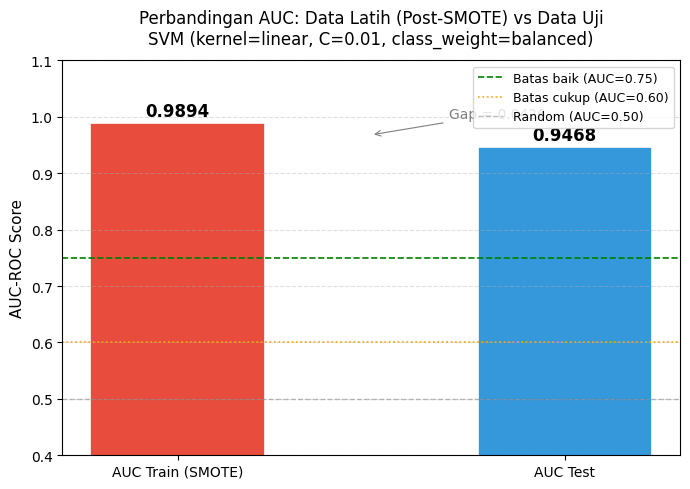


KESIMPULAN DIAGNOSIS OVERFITTING (berbasis AUC)
  AUC Train (post-SMOTE) : 0.9894
  AUC Test               : 0.9468
  Gap                    : 0.0426

  Interpretasi gap:
  - Gap ≤ 0.10 (≤10%) → model tidak menghafal data ✅
  - Gap 0.10-0.15     → sedikit overfit, wajar untuk data kecil ⚠️
  - Gap > 0.15        → model menghafal data, perlu revisitasi parameter ❌


In [38]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PERBANDINGAN AUC DATA LATIH vs DATA UJI
#
# Tujuan: membuktikan model tidak menghafal data (no overfitting).
# Metode: hitung AUC dengan decision_function pada X_smote dan X_test_tfidf.
#
# Catatan teknis:
#   - svm_model adalah SVC yang di-fit langsung pada X_smote (post-SMOTE).
#   - decision_function menghasilkan jarak ke hyperplane SVM.
#   - X_smote     : n_smote_total sampel post-SMOTE (n_train_asli asli + sintetis),
#                   sudah dalam bentuk TF-IDF via tfidf_smote.
#   - X_test_tfidf: n_test_total sampel ASLI, di-transform dengan tfidf dari pipeline.
#
# CATATAN INTERPRETASI PENTING:
#   AUC Train dihitung pada y_smote (termasuk data sintetis SMOTE).
#   AUC Test dihitung pada y_test (data asli murni).
#   Keduanya BUKAN apple-to-apple karena distribusinya berbeda:
#   - Data sintetis lebih 'rapi' secara geometri → AUC Train cenderung
#     lebih tinggi meski tanpa overfitting.
#   - Oleh karena itu, GAP AUC di sini bukan satu-satunya indikator
#     overfitting. Gunakan bersama GAP akurasi (train asli vs test)
#     dari cell Diagnosis Overfitting di atas.
#   Referensi: Blagus & Lusa (2013) — SMOTE inflates apparent performance
#   metrics when test set contains synthetic samples.
# ============================================================

le_auc = LabelEncoder()
# Pakai urutan kelas dari model — konsisten dengan decision_function
le_auc.fit(svm_model.classes_)

y_smote_encoded = le_auc.transform(y_smote)
y_test_encoded  = le_auc.transform(y_test)

# Hitung decision scores dari svm_model (bukan pipeline_svm)
scores_train = svm_model.decision_function(X_smote)
scores_test  = svm_model.decision_function(X_test_tfidf)

auc_train = roc_auc_score(y_smote_encoded, scores_train)
auc_test  = roc_auc_score(y_test_encoded,  scores_test)
auc_gap   = auc_train - auc_test

print("=" * 55)
print("   PERBANDINGAN AUC DATA LATIH vs DATA UJI")
print("=" * 55)
print(f"AUC Data Latih ({n_smote_total} sampel post-SMOTE) : {auc_train:.4f}")
print(f"AUC Data Uji   ({n_test_total} sampel asli)        : {auc_test:.4f}")
print(f"Selisih (Gap)                          : {auc_gap:.4f}  ({auc_gap*100:.2f}%)")
print()

if auc_train >= 0.99 and auc_gap > 0.15:
    status_auc = "❌ OVERFIT — AUC train mendekati sempurna, gap terlalu besar."
    status_auc += "\n   Model menghafal data latih. Coba naikkan min_df atau turunkan C."
elif auc_gap > 0.10:
    status_auc = "⚠️  BORDERLINE — Gap AUC >10%, ada indikasi overfitting ringan."
    status_auc += "\n   Masih bisa diterima untuk dataset kecil (<500 data)."
elif auc_gap <= 0.10 and auc_test >= 0.75:
    status_auc = "✅ TIDAK OVERFIT — Gap AUC kecil, model generalisasi dengan baik."
elif auc_gap <= 0.10 and auc_test >= 0.60:
    status_auc = "✅ TIDAK OVERFIT — Gap kecil. AUC test cukup untuk teks pendek."
else:
    status_auc = "⚠️  AUC test rendah — model mungkin underfit atau data sangat noise."

print(f"Status : {status_auc}")
print()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['AUC Train (SMOTE)', 'AUC Test'],
              [auc_train, auc_test],
              color=['#e74c3c', '#3498db'],
              width=0.45, edgecolor='white', linewidth=1.2)

ax.axhline(y=0.75, color='green', linestyle='--', linewidth=1.2,
           label='Batas baik (AUC=0.75)')
ax.axhline(y=0.60, color='orange', linestyle=':', linewidth=1.2,
           label='Batas cukup (AUC=0.60)')
ax.axhline(y=0.50, color='gray', linestyle='--', linewidth=1, alpha=0.5,
           label='Random (AUC=0.50)')

for bar, val in zip(bars, [auc_train, auc_test]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.annotate(
    f'Gap = {auc_gap:.4f}',
    xy=(0.5, (auc_train + auc_test) / 2),
    xytext=(0.7, (auc_train + auc_test) / 2 + 0.03),
    fontsize=10, color='gray',
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
)

ax.set_title(
    f'Perbandingan AUC: Data Latih (Post-SMOTE) vs Data Uji\n'
    f'SVM (kernel=linear, C={SVM_PARAMS["C"]}, class_weight=balanced)',
    fontsize=12, pad=12
)
ax.set_ylabel('AUC-ROC Score', fontsize=11)
ax.set_ylim(0.4, 1.10)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print()
print("=" * 55)
print("KESIMPULAN DIAGNOSIS OVERFITTING (berbasis AUC)")
print("=" * 55)
print(f"  AUC Train (post-SMOTE) : {auc_train:.4f}")
print(f"  AUC Test               : {auc_test:.4f}")
print(f"  Gap                    : {auc_gap:.4f}")
print()
print("  Interpretasi gap:")
print("  - Gap ≤ 0.10 (≤10%) → model tidak menghafal data ✅")
print("  - Gap 0.10-0.15     → sedikit overfit, wajar untuk data kecil ⚠️")
print("  - Gap > 0.15        → model menghafal data, perlu revisitasi parameter ❌")


# Learning & Validation Curve

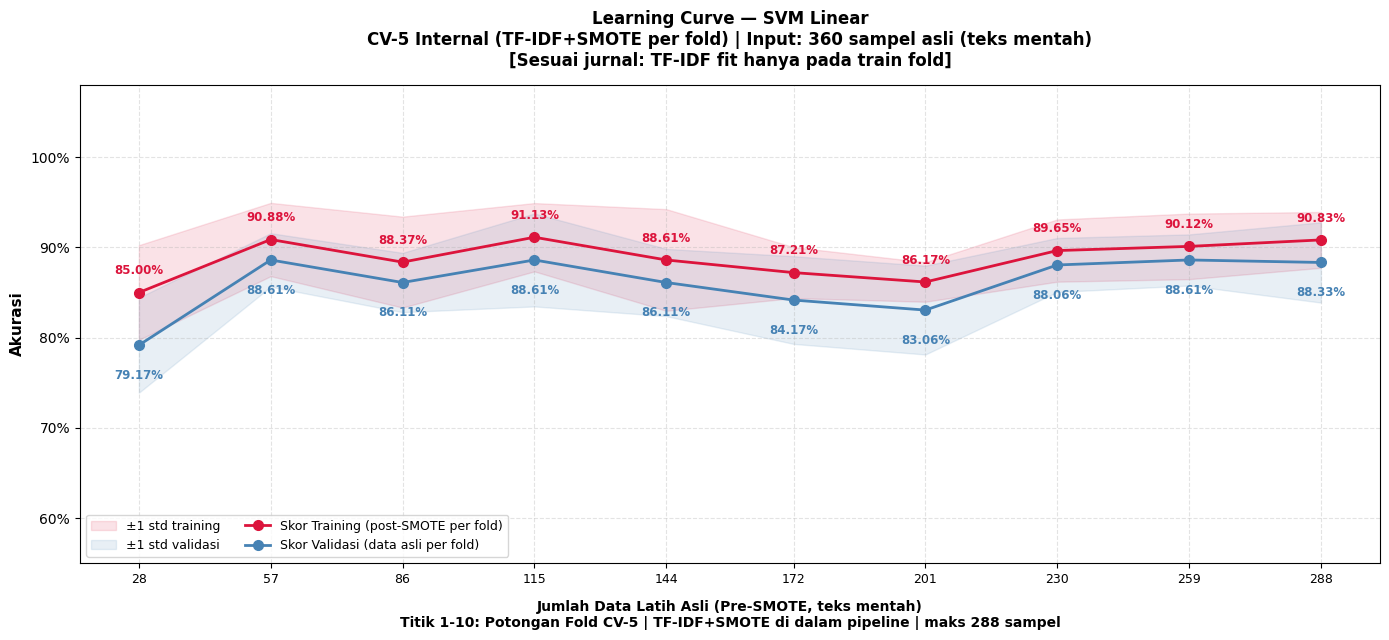

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import learning_curve

# ==============================================================================
# LEARNING CURVE — ImbPipeline(TF-IDF → SMOTE → SVC)
# ==============================================================================
# INPUT: X_train (teks mentah) — bukan X_train_tfidf
# SESUAI JURNAL: TF-IDF di-fit hanya pada training fold tiap CV.
# Fold validasi di-transform menggunakan parameter dari training fold.
# SMOTE juga hanya diterapkan pada training fold.
# ==============================================================================

pipe_lc = ImbPipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('smote', SMOTE(**SMOTE_PARAMS)),
    ('svc',   SVC(**SVM_PARAMS))
])

n_train = len(X_train)
# Batas maksimal training tiap fold CV-5 = 80% dari n_train
fold_train_max = int(n_train * 0.8)
train_sizes_abs = [int(fold_train_max * p) for p in np.linspace(0.1, 1.0, 10)]

train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipe_lc,
    X=X_train,
    y=y_train_arr,
    train_sizes=train_sizes_abs,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(14, 6.5))

ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.12, color='crimson', label='±1 std training')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.12, color='steelblue', label='±1 std validasi')

ax.plot(train_sizes, train_mean, 'o-', color='crimson',   linewidth=2, markersize=7,
        label='Skor Training (post-SMOTE per fold)', zorder=5)
ax.plot(train_sizes, val_mean,   'o-', color='steelblue', linewidth=2, markersize=7,
        label='Skor Validasi (data asli per fold)', zorder=5)

for i, (x, yt, yv) in enumerate(zip(train_sizes, train_mean, val_mean)):
    ax.annotate(f'{yt*100:.2f}%', xy=(x, yt),
                xytext=(0, 11), textcoords='offset points',
                ha='center', va='bottom', fontsize=8.5,
                color='crimson', fontweight='bold')
    ax.annotate(f'{yv*100:.2f}%', xy=(x, yv),
                xytext=(0, -17), textcoords='offset points',
                ha='center', va='top', fontsize=8.5,
                color='steelblue', fontweight='bold')

ax.set_xticks(train_sizes)
ax.set_xticklabels([str(s) for s in train_sizes], fontsize=9)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.set_xlabel(
    f'Jumlah Data Latih Asli (Pre-SMOTE, teks mentah)\n'
    f'Titik 1-10: Potongan Fold CV-5 | TF-IDF+SMOTE di dalam pipeline | maks {fold_train_max} sampel',
    fontsize=10, fontweight='bold', labelpad=10)
ax.set_ylabel('Akurasi', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.set_ylim(0.55, 1.08)
ax.legend(loc='lower left', fontsize=9, ncol=2)
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_title(
    f'Learning Curve — SVM Linear\n'
    f'CV-5 Internal (TF-IDF+SMOTE per fold) | Input: {n_train} sampel asli (teks mentah)\n'
    f'[Sesuai jurnal: TF-IDF fit hanya pada train fold]',
    fontsize=12, pad=14, fontweight='bold')
plt.tight_layout()
plt.show()

Input validation curve : X_train (360 sampel, teks mentah)
Distribusi y_train     : {'negative': 229, 'positive': 131}



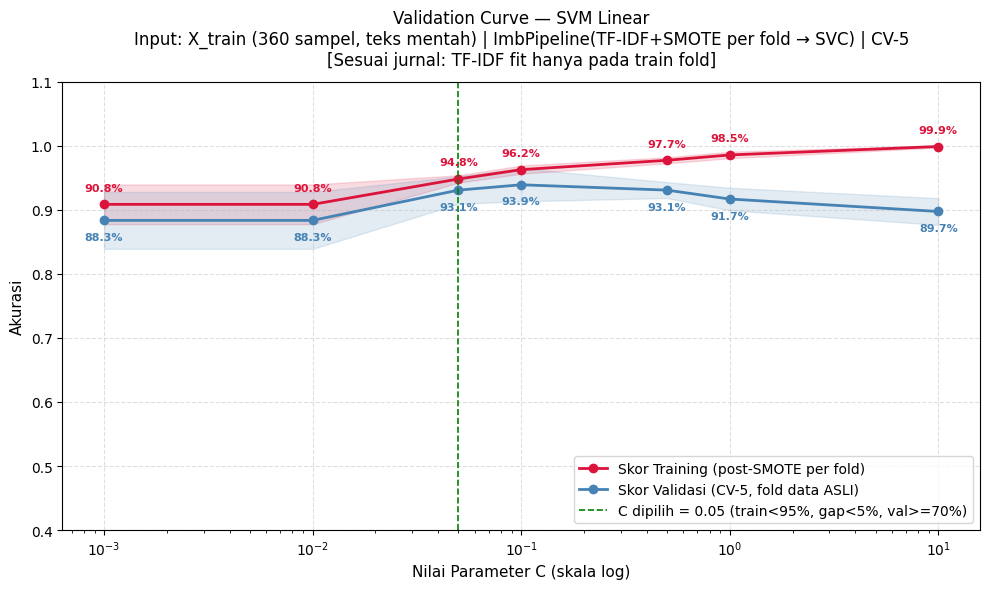

In [40]:
from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt

n_train = len(X_train)

print(f'Input validation curve : X_train ({n_train} sampel, teks mentah)')
print(f'Distribusi y_train     : {dict(sorted(__import__("collections").Counter(y_train_arr).items()))}')
print()

param_range = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 10]

svm_params_no_c = {k: v for k, v in SVM_PARAMS.items() if k != 'C'}
pipe_vc = ImbPipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('smote', SMOTE(**SMOTE_PARAMS)),
    ('svc',   SVC(**svm_params_no_c))
])

train_scores_vc, val_scores_vc = validation_curve(
    estimator=pipe_vc,
    X=X_train,
    y=y_train_arr,
    param_name='svc__C',
    param_range=param_range,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

train_mean_vc = np.mean(train_scores_vc, axis=1)
train_std_vc  = np.std(train_scores_vc, axis=1)
val_mean_vc   = np.mean(val_scores_vc, axis=1)
val_std_vc    = np.std(val_scores_vc, axis=1)

gaps_vc = train_mean_vc - val_mean_vc
kandidat_mask = (
    (train_mean_vc < 0.95) &
    (gaps_vc >= 0)         &
    (gaps_vc < 0.05)       &
    (val_mean_vc >= 0.70)
)

if kandidat_mask.any():
    val_kandidat = np.where(kandidat_mask, val_mean_vc, -1.0)
    idx_terbaik  = int(np.argmax(val_kandidat))
else:
    wajar_mask = (val_mean_vc >= 0.70) & (gaps_vc >= 0)
    if wajar_mask.any():
        gap_filtered = np.where(wajar_mask, gaps_vc, 999.0)
        idx_terbaik  = int(np.argmin(gap_filtered))
    else:
        idx_terbaik  = int(np.argmax(val_mean_vc))

c_terbaik = param_range[idx_terbaik]

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogx(param_range, train_mean_vc, 'o-', color='crimson',
            linewidth=2, markersize=6, label='Skor Training (post-SMOTE per fold)')
ax.fill_between(param_range,
                train_mean_vc - train_std_vc,
                train_mean_vc + train_std_vc,
                alpha=0.15, color='crimson')

ax.semilogx(param_range, val_mean_vc, 'o-', color='steelblue',
            linewidth=2, markersize=6, label='Skor Validasi (CV-5, fold data ASLI)')
ax.fill_between(param_range,
                val_mean_vc - val_std_vc,
                val_mean_vc + val_std_vc,
                alpha=0.15, color='steelblue')

ax.axvline(x=c_terbaik, color='green', linestyle='--', linewidth=1.2,
           label=f'C dipilih = {c_terbaik} (train<95%, gap<5%, val>=70%)')

# Anotasi nilai di setiap titik
for i, c_val in enumerate(param_range):
    ax.text(c_val, train_mean_vc[i] + 0.018,
            f'{train_mean_vc[i]*100:.1f}%',
            ha='center', va='bottom', fontsize=8, color='crimson',
            fontweight='bold', transform=ax.transData)
    ax.text(c_val, val_mean_vc[i] - 0.018,
            f'{val_mean_vc[i]*100:.1f}%',
            ha='center', va='top', fontsize=8, color='steelblue',
            fontweight='bold', transform=ax.transData)

ax.set_title(
    f'Validation Curve — SVM Linear\n'
    f'Input: X_train ({n_train} sampel, teks mentah) | ImbPipeline(TF-IDF+SMOTE per fold → SVC) | CV-5\n'
    f'[Sesuai jurnal: TF-IDF fit hanya pada train fold]',
    fontsize=12, pad=12
)
ax.set_xlabel('Nilai Parameter C (skala log)', fontsize=11)
ax.set_ylabel('Akurasi', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim(0.4, 1.10)
plt.tight_layout()
plt.show()

## 3. Evaluasi Metrik Tambahan: F1-Score & AUC-ROC

Akurasi saja tidak cukup untuk data yang tidak seimbang (64% negatif vs 36% positif). Model yang "malas" menebak selalu negatif pun bisa dapat akurasi 64% tanpa belajar apapun.

- **F1-Score** mengukur keseimbangan antara precision dan recall per kelas — lebih jujur untuk data imbalanced.
- **AUC-ROC** mengukur kemampuan model membedakan dua kelas di berbagai threshold keputusan. Nilai 0.5 = acak, 1.0 = sempurna. Di atas 0.75 dianggap baik untuk NLP teks pendek.

# Stabilisasi & Evaluasi Lanjutan

## 2. Repeated Stratified K-Fold

**Masalah** dengan single 5-fold biasa: standar deviasi tinggi (5.51%) karena satu fold bisa mendapat distribusi data yang "kebetulan mudah" atau "kebetulan sulit". Dengan hanya 381 training sample, efek ini cukup besar.

**Solusi:** `RepeatedStratifiedKFold` menjalankan ulang seluruh proses K-Fold sebanyak `n_repeats` kali dengan pengacakan berbeda tiap ulangan, lalu merata-ratakan semua hasilnya. Efek "keberuntungan" satu fold ternormalisasi karena fold itu akan mendapat komposisi berbeda di ulangan berikutnya.

In [41]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
import numpy as np

# ============================================================
# REPEATED STRATIFIED K-FOLD: 5 fold x 3 ulangan = 15 evaluasi
# ============================================================
# INPUT: X_train (teks mentah, bukan X_train_tfidf)
# SESUAI JURNAL: TF-IDF di-fit hanya pada training fold tiap CV.
#
# Pipeline lengkap: TF-IDF → SMOTE → SVC
# Fold validasi berisi data ASLI → evaluasi valid secara metodologis.
# ============================================================

pipe_rskf = ImbPipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('smote', SMOTE(**SMOTE_PARAMS)),
    ('svc',   SVC(**SVM_PARAMS))
])

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
n_train = len(X_train)

cv_scores_repeated = cross_val_score(
    pipe_rskf,
    X_train, y_train_arr,
    cv=rskf,
    scoring='f1_weighted'
)

print("=" * 65)
print("   HASIL REPEATED STRATIFIED K-FOLD (5-fold x 3 ulangan)")
print("   Metrik: F1-Score Weighted")
print("=" * 65)
print(f"Input          : X_train ({n_train} sampel asli, teks mentah)")
print(f"Pipeline       : ImbPipeline(TF-IDF per fold → SMOTE per fold → SVC)")
print(f"Fold validasi  : data ASLI (tidak mengandung sampel sintetis)")
print(f"[SESUAI JURNAL: TF-IDF fit hanya pada train fold tiap CV]")
print()
for rep in range(3):
    scores_rep = cv_scores_repeated[rep*5:(rep+1)*5]
    print(f"Ulangan {rep+1}: {' | '.join([f'{s*100:.2f}%' for s in scores_rep])}")
    print(f"         Rata-rata: {scores_rep.mean()*100:.2f}%  Std: {scores_rep.std()*100:.2f}%")
    print()

print("-" * 65)
print(f"F1-Score rata-rata keseluruhan (15 fold) : {cv_scores_repeated.mean()*100:.2f}%")
print(f"Standar Deviasi keseluruhan              : {cv_scores_repeated.std()*100:.2f}%")
print("=" * 65)
print()

if cv_scores_repeated.std() < 0.03:
    print("✅ Std < 3% — model stabil lintas distribusi data.")
elif cv_scores_repeated.std() < 0.05:
    print(f"⚠️  Std 3-5% — cukup stabil, masih wajar untuk {n_train} sampel asli.")
else:
    print(f"⚠️  Std > 5% — model masih sensitif terhadap distribusi fold.")
    print("   Ini adalah limitasi ukuran dataset, bukan kesalahan model.")
print()
print(f"Catatan: F1-Score weighted digunakan karena lebih representatif")
print(f"untuk evaluasi pada {n_train} sampel asli (fold validasi = data real).")


   HASIL REPEATED STRATIFIED K-FOLD (5-fold x 3 ulangan)
   Metrik: F1-Score Weighted
Input          : X_train (360 sampel asli, teks mentah)
Pipeline       : ImbPipeline(TF-IDF per fold → SMOTE per fold → SVC)
Fold validasi  : data ASLI (tidak mengandung sampel sintetis)
[SESUAI JURNAL: TF-IDF fit hanya pada train fold tiap CV]

Ulangan 1: 83.57% | 94.49% | 91.81% | 89.08% | 83.66%
         Rata-rata: 88.52%  Std: 4.36%

Ulangan 2: 80.77% | 87.74% | 86.38% | 93.16% | 82.30%
         Rata-rata: 86.07%  Std: 4.37%

Ulangan 3: 94.44% | 85.00% | 91.77% | 86.38% | 93.13%
         Rata-rata: 90.14%  Std: 3.76%

-----------------------------------------------------------------
F1-Score rata-rata keseluruhan (15 fold) : 88.24%
Standar Deviasi keseluruhan              : 4.50%

⚠️  Std 3-5% — cukup stabil, masih wajar untuk 360 sampel asli.

Catatan: F1-Score weighted digunakan karena lebih representatif
untuk evaluasi pada 360 sampel asli (fold validasi = data real).


EVALUASI METRIK TAMBAHAN
F1-Score kelas NEGATIVE  : 88.89%
F1-Score kelas POSITIVE  : 83.33%
F1-Score Macro avg       : 86.11%
F1-Score Weighted avg    : 86.85%
F1-Score Micro avg       : 86.67%

Catatan:
  Macro   = rata-rata F1 tiap kelas, tanpa mempertimbangkan frekuensi kelas.
  Weighted= rata-rata F1 tiap kelas, dibobot proporsi sampel per kelas.
  Micro   = hitung TP/FP/FN total dulu, lalu F1 — untuk binary setara Weighted.

Gap F1 antar kelas 5.6% — sedikit bias, masih wajar.

AUC-ROC Score      : 0.9468

AUC >= 0.90 — model sangat baik membedakan dua kelas.


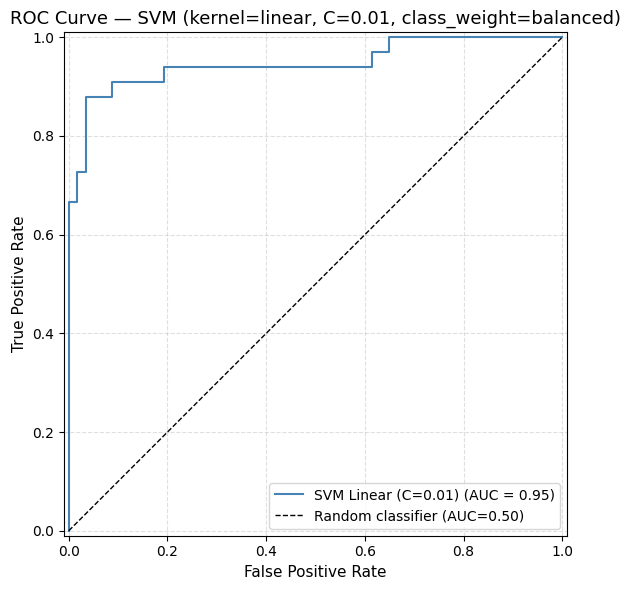


RINGKASAN AKHIR
Akurasi Test      : 86.67%
F1 Macro          : 86.11%
F1 Weighted       : 86.85%
AUC-ROC           : 0.9468
CV Repeated Std   : 4.50%


In [42]:
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                              RocCurveDisplay, classification_report)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# EVALUASI METRIK TAMBAHAN: F1-Score + AUC-ROC
# ============================================================
# AUC-ROC menggunakan decision_function SVM — menghasilkan jarak
# ke hyperplane sebagai skor kontinu. Lebih tepat dari predict_proba
# untuk SVM linear karena tidak memerlukan kalibrasi probabilitas.
# svm_model sudah di-fit pada X_smote (post-SMOTE, jumlah sampel dinamis).
# ============================================================

# --- F1-Score per kelas ---
f1_per_kelas = f1_score(y_test, predicted_test, average=None,
                        labels=list(svm_model.classes_), zero_division=0)
f1_macro     = f1_score(y_test, predicted_test, average='macro',    zero_division=0)
f1_weighted  = f1_score(y_test, predicted_test, average='weighted', zero_division=0)
f1_micro     = f1_score(y_test, predicted_test, average='micro',    zero_division=0)

print('=' * 55)
print('EVALUASI METRIK TAMBAHAN')
print('=' * 55)
for cls, score in zip(svm_model.classes_, f1_per_kelas):
    print(f'F1-Score kelas {cls.upper():<10}: {score*100:.2f}%')
print(f'F1-Score Macro avg       : {f1_macro*100:.2f}%')
print(f'F1-Score Weighted avg    : {f1_weighted*100:.2f}%')
print(f'F1-Score Micro avg       : {f1_micro*100:.2f}%')
print()
print('Catatan:')
print('  Macro   = rata-rata F1 tiap kelas, tanpa mempertimbangkan frekuensi kelas.')
print('  Weighted= rata-rata F1 tiap kelas, dibobot proporsi sampel per kelas.')
print('  Micro   = hitung TP/FP/FN total dulu, lalu F1 — untuk binary setara Weighted.')
print()

gap_f1 = abs(f1_per_kelas[0] - f1_per_kelas[1])
if gap_f1 < 0.05:
    print('Gap F1 antar kelas < 5% — model seimbang.')
elif gap_f1 < 0.10:
    print(f'Gap F1 antar kelas {gap_f1*100:.1f}% — sedikit bias, masih wajar.')
else:
    print(f'Gap F1 antar kelas {gap_f1*100:.1f}% — model bias ke satu kelas.')

# --- AUC-ROC ---
# LabelEncoder di-fit dari svm_model.classes_ agar urutan encoding
# konsisten dengan urutan kelas yang dipelajari model.
# svm_model.classes_ = ['negative', 'positive'] → encode: 0=negative, 1=positive
print()
svm_scores = svm_model.decision_function(X_test_tfidf)

le = LabelEncoder()
le.fit(svm_model.classes_)           # fit dari kelas model, bukan dari y_test
y_test_encoded = le.transform(y_test)

auc_score = roc_auc_score(y_test_encoded, svm_scores)
print(f'AUC-ROC Score      : {auc_score:.4f}')
print()
if auc_score >= 0.90:
    print('AUC >= 0.90 — model sangat baik membedakan dua kelas.')
elif auc_score >= 0.75:
    print('AUC >= 0.75 — model baik, layak untuk data teks pendek.')
elif auc_score >= 0.60:
    print('AUC 0.60-0.75 — model cukup, masih bisa ditingkatkan.')
else:
    print('AUC < 0.60 — model hampir tidak lebih baik dari tebakan acak.')

# --- Plot ROC Curve ---
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test_encoded, svm_scores,
    name=f'SVM Linear (C={SVM_PARAMS["C"]})',
    ax=ax, color='steelblue'
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier (AUC=0.50)')
ax.set_title(
    f'ROC Curve — SVM (kernel=linear, C={SVM_PARAMS["C"]}, class_weight=balanced)',
    fontsize=13
)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- Ringkasan akhir ---
print()
print('=' * 55)
print('RINGKASAN AKHIR')
print('=' * 55)
print(f'Akurasi Test      : {accuracy_score(y_test, predicted_test)*100:.2f}%')
print(f'F1 Macro          : {f1_macro*100:.2f}%')
print(f'F1 Weighted       : {f1_weighted*100:.2f}%')
print(f'AUC-ROC           : {auc_score:.4f}')
print(f'CV Repeated Std   : {cv_scores_repeated.std()*100:.2f}%')